# NCD mortality forecasting: reproducibility notebook aligned with the revised manuscript

Run all cells from a fresh kernel, in order. Place the four retained CSV exports beside
this notebook, or change `INPUT_DIR` below. No source CSVs are embedded in this notebook.
The covariance figures are generated separately by `GPKernels_Revised.ipynb`.

**Reproducibility status:** this notebook has been executed using the retained WHO mortality
CSV and the three World Bank population exports used in the revised manuscript. The saved
outputs reproduce the primary hold-out evaluation, five-fold rolling-origin sensitivity analysis,
final 2000–2019 refits and 2020–2030 forecasts, data audits, and manuscript-table verification.
Input-file SHA-256 checksums and execution-environment information are exported during the run.

- Primary evaluation: 84 series, training 2000–2014 (15 points), testing 2015–2019 (5 points).
- Rolling sensitivity analysis: origins 2010–2014, five test years per origin; overlapping windows.
- Both GPR models: 10 additional optimiser restarts, random seed 42, training-only scaling.
- Final composite-GPR refits: all 20 observations from 2000–2019; forecasts 2020–2030.
- Male/female counts use the corresponding male/female population; both sexes use total population.
- Countries form an illustrative cohort, not a representative sample. The USA is for visualisation only.

Check `Manuscript_Table_Check.csv` and the data-audit outputs before submission.

In [1]:
from pathlib import Path
import csv
import hashlib
import json
import marshal
from importlib.metadata import version as package_version
import gc
import os
import platform
import sys
import warnings

# Limit native numerical libraries to one thread. Thousands of short GPR
# optimisations do not benefit from thread oversubscription, which can make a
# notebook unresponsive or cause the operating system to terminate its kernel.
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")
os.environ.setdefault("NUMEXPR_NUM_THREADS", "1")
os.environ.setdefault("BLIS_NUM_THREADS", "1")
os.environ.setdefault("VECLIB_MAXIMUM_THREADS", "1")
os.environ.setdefault("LOKY_MAX_CPU_COUNT", "1")

import matplotlib.pyplot as plt
from matplotlib.backends.backend_agg import FigureCanvasAgg
from matplotlib.figure import Figure
import numpy as np
import pandas as pd
import sklearn
import scipy
import matplotlib
from sklearn.exceptions import ConvergenceWarning
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import (
    Matern,
    RBF,
    RationalQuadratic,
    WhiteKernel,
)
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
from threadpoolctl import threadpool_limits

try:
    from IPython.display import Image as IPythonImage, display
except ImportError:
    IPythonImage = None
    display = print

# Convergence warnings are captured per fit and exported with the fit metadata.
# They are not silently discarded.

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

print("Python:", sys.version.split()[0])
print("Platform:", platform.platform())
print("NumPy:", np.__version__)
print("pandas:", pd.__version__)
print("scikit-learn:", sklearn.__version__)
print("Native numerical-library threads: limited to 1")


Python: 3.14.6
Platform: Windows-11-10.0.26200-SP0
NumPy: 2.4.6
pandas: 3.0.3
scikit-learn: 1.9.0
Native numerical-library threads: limited to 1


In [2]:
# Use the original archived exports, not newly downloaded replacement data.
INPUT_DIR = Path(".")
EXPECTED_WHO_SHA256 = "b3967075389134dd0aca5d4dae7815d0afcdec218aaf2a77ec2c9080e2197483"
EXPECTED_WB_UPDATE_DATE = "2026-07-13"
def resolve_input_file(*candidate_names):
    """Return the first existing candidate, preserving a clear error if absent."""
    for candidate_name in candidate_names:
        candidate = INPUT_DIR / candidate_name
        if candidate.exists():
            return candidate
    return INPUT_DIR / candidate_names[0]


WHO_FILE = resolve_input_file("NoD_to_NCD.csv")
TOTAL_POPULATION_FILE = resolve_input_file(
    "Population_Total(1).csv", "Population_Total.csv"
)
FEMALE_POPULATION_FILE = resolve_input_file(
    "Population_Female(1).csv", "Population_Female.csv"
)
MALE_POPULATION_FILE = resolve_input_file(
    "Population_Male(1).csv", "Population_Male.csv"
)

OUTPUT_DIR = Path("GPR_Research_Results_Sex_Specific")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42

# Each fit starts at the declared kernel parameters and uses 10 additional
# random initialisations. The same setting applies to both GPR models.
PRIMARY_N_RESTARTS = 10
ROLLING_N_RESTARTS = 10
FINAL_N_RESTARTS = 10
GPR_ALPHA = 1e-10
NORMALIZE_Y = False
GPR_OPTIMIZER = "fmin_l_bfgs_b"

# Checkpoints are saved during execution. Reuse is disabled for a clean run;
# set the corresponding flag to True only to resume compatible saved work.
RESUME_ROLLING_FROM_CHECKPOINTS = False
RESUME_HOLDOUT_FROM_CHECKPOINT = False
HOLDOUT_CHECKPOINT_DIR = OUTPUT_DIR / "Holdout_Checkpoint"
HOLDOUT_CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
ROLLING_CHECKPOINT_DIR = OUTPUT_DIR / "Rolling_Origin_Checkpoints"
ROLLING_CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

# Publication-output controls. Every generated figure is saved and displayed
# from a PNG file only. A 300-dpi raster is suitable for manuscript review.
RASTER_DPI = 300
GENERATE_BOTH_SEX_FIGURES = True
DISPLAY_FIGURE_PREVIEWS = True
RESUME_FINAL_FROM_CACHE = False
BOTH_SEX_FIGSIZE = (12.0, 4.4)
SEX_SPECIFIC_FIGSIZE = (15.5, 15.0)
EXPORT_OPTIONAL_TIFF = False

START_YEAR = 2000
END_YEAR = 2019

TRAIN_END_YEAR = 2014
TEST_START_YEAR = 2015
TEST_END_YEAR = 2019

ROLLING_ORIGINS = [2010, 2011, 2012, 2013, 2014]
FORECAST_HORIZON = 5

FINAL_FORECAST_START = 2020
FINAL_FORECAST_END = 2030

SEX_CATEGORIES = ["Both sexes", "Male", "Female"]

# These three World Bank files were downloaded from the same release.
# Stop if their direct and sex-derived totals differ by more than 0.01%.
MAX_SEX_DERIVED_TOTAL_GAP_PCT = 0.01


In [3]:
# Countries used for the formal hold-out and rolling-origin evaluation.
countries = [
    "China",
    "United Kingdom of Great Britain and Northern Ireland",
    "Nigeria",
    "Bangladesh",
    "Sri Lanka",
    "India",
    "South Africa",
]

# Countries used in the manuscript's sex-specific multi-panel figure.
SEX_SPECIFIC_FIGURE_COUNTRIES = [
    "United States of America",
    "United Kingdom of Great Britain and Northern Ireland",
    "India",
    "South Africa",
]

# Prepare the union once; evaluation below is explicitly restricted to
# `countries`, so adding the United States for plotting does not alter the
# reported seven-country validation cohort.
data_countries = list(dict.fromkeys(countries + SEX_SPECIFIC_FIGURE_COUNTRIES))

diseases = [
    "Cardiovascular diseases",
    "Respiratory diseases",
    "Diabetes mellitus",
    "Malignant neoplasms",
]

EXPECTED_DISEASE_CODES = {
    "Cardiovascular diseases": "GHECAUSES_GHE110",
    "Respiratory diseases": "GHECAUSES_GHE117",
    "Diabetes mellitus": "GHECAUSES_GHE080",
    "Malignant neoplasms": "GHECAUSES_GHE061",
}

EXPECTED_SEX_CODES = {
    "Both sexes": "SEX_BTSX",
    "Male": "SEX_MLE",
    "Female": "SEX_FMLE",
}

EXPECTED_NUMBER_OF_SERIES = len(countries) * len(diseases) * len(SEX_CATEGORIES)
EXPECTED_NUMBER_OF_PREPARED_SERIES = (
    len(data_countries) * len(diseases) * len(SEX_CATEGORIES)
)
EXPECTED_YEARS = set(range(START_YEAR, END_YEAR + 1))

print("Evaluation country–disease–sex series:", EXPECTED_NUMBER_OF_SERIES)
print("Prepared country–disease–sex series:", EXPECTED_NUMBER_OF_PREPARED_SERIES)

Evaluation country–disease–sex series: 84
Prepared country–disease–sex series: 96


## Input provenance and environment

The WHO checksum and World Bank update date below come from Manuscript V23.
A mismatch stops the manuscript reproduction run. SHA-256 values for all four
files and the actual execution environment are exported when this cell runs.
An update date alone does not prove that population exports are byte-identical.


In [4]:
input_files = {"WHO mortality": WHO_FILE, "Total population": TOTAL_POPULATION_FILE,
               "Female population": FEMALE_POPULATION_FILE, "Male population": MALE_POPULATION_FILE}
input_manifest = []
for role, path in input_files.items():
    if not path.is_file():
        raise FileNotFoundError(f"Missing original {role} CSV: {path.resolve()}")
    checksum = hashlib.sha256(path.read_bytes()).hexdigest()
    input_manifest.append({"Role": role, "Filename": path.name,
                           "Bytes": path.stat().st_size, "SHA256": checksum})
pd.DataFrame(input_manifest).to_csv(OUTPUT_DIR / "Input_File_Manifest.csv", index=False)
if input_manifest[0]["SHA256"] != EXPECTED_WHO_SHA256:
    raise ValueError("WHO file differs from the SHA-256 recorded in Manuscript V23; check the archive.")
environment = {"Python": platform.python_version(), "Platform": platform.platform()}
for package in ["numpy", "pandas", "scipy", "scikit-learn", "matplotlib", "threadpoolctl", "Pillow", "IPython"]:
    environment[package] = package_version(package)
(OUTPUT_DIR / "Execution_Environment.json").write_text(json.dumps(environment, indent=2), encoding="utf-8")
display(pd.DataFrame(input_manifest))


,Role,Filename,Bytes,SHA256
0,WHO mortality,NoD_to_NCD.csv,13365625,b3967075389134dd0aca5d4dae7815d0afcdec218aaf2a...
1,Total population,Population_Total.csv,195734,097e1a1fd3551f88868d23310c13a4a9d2ca4d84c91592...
2,Female population,Population_Female.csv,192625,f618d2e772d971cc54e4e7cd6ee262fed6df5511da8f56...
3,Male population,Population_Male.csv,155441,7742399ce17e53b3ef1b89d7041735231404f305fd377b...


## 2. Load and audit the WHO mortality data


In [5]:
if not WHO_FILE.exists():
    raise FileNotFoundError(f"WHO file not found: {WHO_FILE.resolve()}")

df = pd.read_csv(WHO_FILE)

required_who_columns = [
    "IndicatorCode", "Indicator", "SpatialDimValueCode", "Location",
    "Period", "Dim1", "Dim1ValueCode", "Dim2", "Dim2ValueCode",
    "FactValueNumeric",
]
missing_who_columns = [c for c in required_who_columns if c not in df.columns]
if missing_who_columns:
    raise ValueError(f"Required WHO columns are missing: {missing_who_columns}")

expected_indicator = "SDG_SH_DTH_RNCOM"
indicator_codes = set(df["IndicatorCode"].dropna().astype(str).str.strip())
if indicator_codes != {expected_indicator}:
    raise ValueError(
        f"Expected only WHO indicator {expected_indicator}; found {sorted(indicator_codes)}"
    )

observed_disease_codes = (
    df[["Dim2", "Dim2ValueCode"]].drop_duplicates().set_index("Dim2")["Dim2ValueCode"].to_dict()
)
observed_sex_codes = (
    df[["Dim1", "Dim1ValueCode"]].drop_duplicates().set_index("Dim1")["Dim1ValueCode"].to_dict()
)
for label, expected_code in EXPECTED_DISEASE_CODES.items():
    if observed_disease_codes.get(label) != expected_code:
        raise ValueError(f"Unexpected WHO disease code for {label}")
for label, expected_code in EXPECTED_SEX_CODES.items():
    if observed_sex_codes.get(label) != expected_code:
        raise ValueError(f"Unexpected WHO sex code for {label}")

analytical_who = df[
    df["Location"].isin(data_countries)
    & df["Dim2"].isin(diseases)
    & df["Dim1"].isin(SEX_CATEGORIES)
].copy()
analytical_who["Period"] = pd.to_numeric(analytical_who["Period"], errors="coerce")
analytical_who["FactValueNumeric"] = pd.to_numeric(
    analytical_who["FactValueNumeric"], errors="coerce"
)
selected_before_year_filter = analytical_who.copy()
invalid_year = (~np.isfinite(selected_before_year_filter["Period"])
                | (selected_before_year_filter["Period"] % 1 != 0))
pre_year_audit = pd.DataFrame({
    "Item": ["Selected rows before year restriction", "Missing or invalid years",
             "Valid rows outside 2000-2019"],
    "Count": [len(selected_before_year_filter), int(invalid_year.sum()),
              int((~invalid_year & ~selected_before_year_filter["Period"].between(START_YEAR, END_YEAR)).sum())],
})
pre_year_audit.to_csv(OUTPUT_DIR / "WHO_Pre_Year_Filter_Audit.csv", index=False)
if invalid_year.any():
    selected_before_year_filter.loc[invalid_year].to_csv(
        OUTPUT_DIR / "WHO_Invalid_Year_Records.csv", index=False)
    raise ValueError("Missing/invalid WHO years before filtering; resolve against the source.")
analytical_who = selected_before_year_filter[
    selected_before_year_filter["Period"].between(START_YEAR, END_YEAR, inclusive="both")
].copy()

duplicate_key = ["SpatialDimValueCode", "Period", "Dim1", "Dim2"]
duplicate_mask = analytical_who.duplicated(duplicate_key, keep=False)
missing_value_mask = analytical_who[["Period", "FactValueNumeric"]].isna().any(axis=1)

data_preparation_audit = pd.DataFrame(
    {
        "Item": [
            "Rows in WHO source file",
            "Rows in selected countries/diseases/sexes/years",
            "Duplicate analytical rows",
            "Rows with missing year or death value",
            "Rows retained for analysis",
        ],
        "Count": [
            len(df), len(analytical_who), int(duplicate_mask.sum()),
            int(missing_value_mask.sum()),
            int((~duplicate_mask & ~missing_value_mask).sum()),
        ],
    }
)
data_preparation_audit.to_csv(OUTPUT_DIR / "WHO_Data_Preparation_Audit.csv", index=False)
display(data_preparation_audit)

if duplicate_mask.any():
    analytical_who.loc[duplicate_mask].to_csv(
        OUTPUT_DIR / "WHO_Duplicate_Analytical_Records.csv", index=False
    )
    raise ValueError("Duplicate WHO analytical rows found; no rows were removed silently.")
if missing_value_mask.any():
    analytical_who.loc[missing_value_mask].to_csv(
        OUTPUT_DIR / "WHO_Missing_Analytical_Records.csv", index=False
    )
    raise ValueError("Missing WHO analytical values found; no rows were removed silently.")

country_code_crosswalk = (
    analytical_who[["Location", "SpatialDimValueCode"]]
    .drop_duplicates()
    .sort_values("Location")
    .reset_index(drop=True)
)
counts_per_country = country_code_crosswalk.groupby("Location").size()
if set(country_code_crosswalk["Location"]) != set(data_countries) or not counts_per_country.eq(1).all():
    raise ValueError("Each selected WHO country must map to exactly one country code.")
country_code_crosswalk.to_csv(OUTPUT_DIR / "Country_Code_Crosswalk.csv", index=False)
display(country_code_crosswalk)

,Item,Count
0,Rows in WHO source file,43920
1,Rows in selected countries/diseases/sexes/years,1920
2,Duplicate analytical rows,0
3,Rows with missing year or death value,0
4,Rows retained for analysis,1920


,Location,SpatialDimValueCode
0,Bangladesh,BGD
1,China,CHN
2,India,IND
3,Nigeria,NGA
4,South Africa,ZAF
5,Sri Lanka,LKA
6,United Kingdom of Great Britain and Northern I...,GBR
7,United States of America,USA


## 3. Build sex-matched World Bank population denominators


In [6]:
def load_world_bank_indicator(filename, allowed_indicator_codes, start_year, end_year):
    filename = Path(filename)
    if not filename.exists():
        raise FileNotFoundError(f"World Bank file not found: {filename.resolve()}")

    population = pd.read_csv(filename, skiprows=4)
    population.columns = population.columns.astype(str).str.strip()
    required = ["Country Name", "Country Code", "Indicator Name", "Indicator Code"]
    missing = [c for c in required if c not in population.columns]
    if missing:
        raise ValueError(f"Missing World Bank columns in {filename.name}: {missing}")

    indicator_codes = population["Indicator Code"].dropna().astype(str).str.strip().unique()
    if len(indicator_codes) != 1 or indicator_codes[0] not in allowed_indicator_codes:
        raise ValueError(
            f"Unexpected indicator in {filename.name}. Allowed: {sorted(allowed_indicator_codes)}; "
            f"found: {indicator_codes.tolist()}"
        )

    year_columns = [str(y) for y in range(start_year, end_year + 1)]
    missing_years = [y for y in year_columns if y not in population.columns]
    if missing_years:
        raise ValueError(f"Missing years in {filename.name}: {missing_years}")

    population = population[required + year_columns].copy()
    duplicate_codes = population["Country Code"].duplicated(keep=False)
    if duplicate_codes.any():
        population.loc[duplicate_codes].to_csv(
            OUTPUT_DIR / f"{filename.stem}_Duplicate_Country_Codes.csv", index=False
        )
        raise ValueError(f"Duplicate country codes found in {filename.name}")
    return population, indicator_codes[0]


def world_bank_to_long(wide, value_name, start_year, end_year):
    year_columns = [str(y) for y in range(start_year, end_year + 1)]
    long = wide.melt(
        id_vars=["Country Name", "Country Code", "Indicator Name", "Indicator Code"],
        value_vars=year_columns,
        var_name="Year",
        value_name=value_name,
    )
    long["Year"] = pd.to_numeric(long["Year"], errors="raise").astype(int)
    long[value_name] = pd.to_numeric(long[value_name], errors="coerce")
    if long.duplicated(["Country Code", "Year"], keep=False).any():
        raise ValueError(f"Duplicate country-year rows in {value_name}")
    return long


def world_bank_update_date(filename):
    with Path(filename).open("r", encoding="utf-8-sig", newline="") as handle:
        for row in csv.reader(handle):
            if row and row[0].strip() == "Last Updated Date":
                raw_date = row[1].strip()
                # World Bank exports may represent the same date as either
                # YYYY-MM-DD or DD/MM/YYYY.
                day_first = "/" in raw_date
                return pd.to_datetime(
                    raw_date, dayfirst=day_first, errors="raise"
                ).date().isoformat()
    raise ValueError(f"Last Updated Date metadata not found in {filename}")


total_wide, total_indicator_code = load_world_bank_indicator(
    TOTAL_POPULATION_FILE, {"SP.POP.TOTL"}, START_YEAR, END_YEAR
)
female_wide, female_indicator_code = load_world_bank_indicator(
    FEMALE_POPULATION_FILE, {"SP.POP.TOTL.FE.IN"}, START_YEAR, END_YEAR
)
male_wide, male_indicator_code = load_world_bank_indicator(
    MALE_POPULATION_FILE,
    {"SP.POP.TOTL.MA.IN"},
    START_YEAR,
    END_YEAR,
)

population_update_dates = {
    "Total": world_bank_update_date(TOTAL_POPULATION_FILE),
    "Female": world_bank_update_date(FEMALE_POPULATION_FILE),
    "Male source": world_bank_update_date(MALE_POPULATION_FILE),
}
if len(set(population_update_dates.values())) != 1:
    raise ValueError(
        "The World Bank population files have different update dates: "
        f"{population_update_dates}. Download them together and rerun."
    )

if set(population_update_dates.values()) != {EXPECTED_WB_UPDATE_DATE}:
    raise ValueError("Population export date differs from Manuscript V23 (2026-07-13).")
print("Total population indicator:", total_indicator_code)
print("Female population indicator:", female_indicator_code)
print("Supplied male-file indicator:", male_indicator_code)
print("World Bank update date:", next(iter(population_update_dates.values())))

Total population indicator: SP.POP.TOTL
Female population indicator: SP.POP.TOTL.FE.IN
Supplied male-file indicator: SP.POP.TOTL.MA.IN
World Bank update date: 2026-07-13


In [7]:
total_long = world_bank_to_long(total_wide, "TotalPopulation", START_YEAR, END_YEAR)
female_long = world_bank_to_long(female_wide, "FemalePopulation", START_YEAR, END_YEAR)
male_source_long = world_bank_to_long(male_wide, "MaleSourceValue", START_YEAR, END_YEAR)

component_population = female_long[
    ["Country Code", "Year", "Country Name", "FemalePopulation"]
].merge(
    male_source_long[["Country Code", "Year", "MaleSourceValue"]],
    on=["Country Code", "Year"],
    how="outer",
    validate="one_to_one",
)
required_country_codes = set(country_code_crosswalk["SpatialDimValueCode"])
component_population = component_population[
    component_population["Country Code"].isin(required_country_codes)
    & component_population["Year"].between(START_YEAR, END_YEAR)
].copy()

# Direct male population counts are required by the manuscript protocol.
component_population["MalePopulation"] = component_population["MaleSourceValue"]
component_population["MaleSharePercent"] = 100 * (
    component_population["MalePopulation"]
    / (component_population["MalePopulation"] + component_population["FemalePopulation"])
)
male_denominator_method = "Direct World Bank male population count"
male_denominator_indicator = "SP.POP.TOTL.MA.IN"

component_population["SexDerivedTotal"] = (
    component_population["FemalePopulation"] + component_population["MalePopulation"]
)

population_audit = total_long[
    ["Country Code", "Year", "Country Name", "TotalPopulation"]
].merge(
    component_population[
        [
            "Country Code", "Year", "FemalePopulation", "MalePopulation",
            "MaleSharePercent", "SexDerivedTotal",
        ]
    ],
    on=["Country Code", "Year"],
    how="outer",
    validate="one_to_one",
)
population_audit["SexDerivedMinusDirectTotal"] = (
    population_audit["SexDerivedTotal"] - population_audit["TotalPopulation"]
)
population_audit["AbsoluteGapPercentOfDirectTotal"] = 100 * (
    population_audit["SexDerivedMinusDirectTotal"].abs()
    / population_audit["TotalPopulation"]
)

selected_population_audit = population_audit[
    population_audit["Country Code"].isin(required_country_codes)
    & population_audit["Year"].between(START_YEAR, END_YEAR)
].copy()
selected_population_audit.to_csv(
    OUTPUT_DIR / "Population_Denominator_Consistency_Audit.csv", index=False
)

missing_population = selected_population_audit[
    ["TotalPopulation", "FemalePopulation", "MalePopulation"]
].isna().any(axis=1)
if missing_population.any():
    raise ValueError("Missing population denominator(s) for a selected country-year.")

nonpositive_population = (
    selected_population_audit[["TotalPopulation", "FemalePopulation", "MalePopulation"]] <= 0
).any(axis=1)
if nonpositive_population.any():
    raise ValueError("Non-positive population denominator(s) found.")

maximum_gap = selected_population_audit["AbsoluteGapPercentOfDirectTotal"].max()
print(f"Maximum direct-total vs sex-derived-total gap: {maximum_gap:.3f}%")
if maximum_gap > MAX_SEX_DERIVED_TOTAL_GAP_PCT:
    raise ValueError(
        f"Population files are inconsistent: maximum gap {maximum_gap:.3f}% exceeds "
        f"the {MAX_SEX_DERIVED_TOTAL_GAP_PCT:.3f}% tolerance. Download all three "
        "World Bank indicators at the same time and rerun."
    )
if maximum_gap > 0.001:
    warnings.warn(
        "The direct total and the sex-derived total differ by more than 0.001% for at "
        "least one selected country-year. See Population_Denominator_Consistency_Audit.csv."
    )

display(
    selected_population_audit.groupby("Country Code")["AbsoluteGapPercentOfDirectTotal"]
    .agg(["mean", "max"]).round(3)
)


Maximum direct-total vs sex-derived-total gap: 0.000%


,mean,max
Country Code,,
BGD,0.0,0.0
CHN,0.0,0.0
GBR,0.0,0.0
IND,0.0,0.0
LKA,0.0,0.0
NGA,0.0,0.0
USA,0.0,0.0
ZAF,0.0,0.0


In [8]:
both_population = total_long[
    ["Country Code", "Year", "TotalPopulation"]
].rename(columns={"TotalPopulation": "Population"})
both_population["Sex"] = "Both sexes"
both_population["Denominator Indicator"] = "SP.POP.TOTL"
both_population["Denominator Method"] = "Direct World Bank total population count"

female_population = component_population[
    ["Country Code", "Year", "FemalePopulation"]
].rename(columns={"FemalePopulation": "Population"})
female_population["Sex"] = "Female"
female_population["Denominator Indicator"] = "SP.POP.TOTL.FE.IN"
female_population["Denominator Method"] = "Direct World Bank female population count"

male_population = component_population[
    ["Country Code", "Year", "MalePopulation"]
].rename(columns={"MalePopulation": "Population"})
male_population["Sex"] = "Male"
male_population["Denominator Indicator"] = male_denominator_indicator
male_population["Denominator Method"] = male_denominator_method

population_by_sex = pd.concat(
    [both_population, male_population, female_population], ignore_index=True
)
population_by_sex = population_by_sex[
    population_by_sex["Country Code"].isin(required_country_codes)
    & population_by_sex["Year"].between(START_YEAR, END_YEAR)
].copy()

if population_by_sex.duplicated(["Country Code", "Year", "Sex"], keep=False).any():
    raise ValueError("Duplicate country-year-sex population denominators found.")

expected_population_rows = len(required_country_codes) * len(EXPECTED_YEARS) * len(SEX_CATEGORIES)
if len(population_by_sex) != expected_population_rows:
    raise ValueError(
        f"Expected {expected_population_rows} population rows; found {len(population_by_sex)}."
    )

denominator_values = population_by_sex["Population"].to_numpy(dtype=float)
if not np.isfinite(denominator_values).all() or (denominator_values <= 0).any():
    raise ValueError("Population denominators must all be finite and positive.")
pd.DataFrame({
    "Item": ["Expected country-year-sex denominators", "Retained denominators",
             "Missing/non-finite denominators", "Non-positive denominators", "Duplicate keys"],
    "Count": [expected_population_rows, len(population_by_sex),
              int((~np.isfinite(denominator_values)).sum()), int((denominator_values <= 0).sum()),
              int(population_by_sex.duplicated(["Country Code", "Year", "Sex"]).sum())],
}).to_csv(OUTPUT_DIR / "Population_Denominator_Count_Audit.csv", index=False)
population_by_sex.to_csv(OUTPUT_DIR / "Population_Denominators_Used.csv", index=False)
display(population_by_sex.head())


,Country Code,Year,Population,Sex,Denominator Indicator,Denominator Method
20,BGD,2000,1.345443e+08,Both sexes,SP.POP.TOTL,Direct World Bank total population count
40,CHN,2000,1.262645e+09,Both sexes,SP.POP.TOTL,Direct World Bank total population count
80,GBR,2000,5.889251e+07,Both sexes,SP.POP.TOTL,Direct World Bank total population count
108,IND,2000,1.057923e+09,Both sexes,SP.POP.TOTL,Direct World Bank total population count
137,LKA,2000,1.929305e+07,Both sexes,SP.POP.TOTL,Direct World Bank total population count


## 4. Construct all country–disease–sex mortality-rate series


In [9]:
def prepare_ncd_series(who_data, population_data, country, disease, sex):
    selected = who_data[
        (who_data["Location"] == country)
        & (who_data["Dim2"] == disease)
        & (who_data["Dim1"] == sex)
    ].copy()

    if selected.empty:
        raise ValueError(f"No WHO data for {country} / {disease} / {sex}")
    selected["Period"] = pd.to_numeric(selected["Period"], errors="raise").astype(int)
    selected["FactValueNumeric"] = pd.to_numeric(
        selected["FactValueNumeric"], errors="coerce"
    )
    selected = selected[selected["Period"].between(START_YEAR, END_YEAR)].copy()

    if selected["Period"].duplicated(keep=False).any():
        raise ValueError(f"Duplicate WHO years for {country} / {disease} / {sex}")
    if set(selected["Period"]) != EXPECTED_YEARS:
        missing = sorted(EXPECTED_YEARS - set(selected["Period"]))
        extra = sorted(set(selected["Period"]) - EXPECTED_YEARS)
        raise ValueError(
            f"Incorrect WHO coverage for {country} / {disease} / {sex}; "
            f"missing={missing}, extra={extra}"
        )
    if selected["FactValueNumeric"].isna().any():
        raise ValueError(f"Missing death count for {country} / {disease} / {sex}")
    if (selected["FactValueNumeric"] < 0).any():
        raise ValueError(f"Negative death count for {country} / {disease} / {sex}")

    country_codes = selected["SpatialDimValueCode"].dropna().astype(str).unique()
    if len(country_codes) != 1:
        raise ValueError(f"Expected one WHO country code for {country}; found {country_codes}")

    sex_population = population_data[population_data["Sex"] == sex].copy()
    merged = selected.merge(
        sex_population,
        left_on=["SpatialDimValueCode", "Period", "Dim1"],
        right_on=["Country Code", "Year", "Sex"],
        how="left",
        validate="one_to_one",
    )
    if merged["Population"].isna().any():
        missing_years = merged.loc[merged["Population"].isna(), "Period"].tolist()
        raise ValueError(
            f"Missing {sex} population for {country} / {disease}; years={missing_years}"
        )
    if (merged["Population"] <= 0).any():
        raise ValueError(f"Non-positive population for {country} / {disease} / {sex}")

    merged["MortalityRatePer100k"] = (
        merged["FactValueNumeric"] / merged["Population"] * 100000.0
    )
    if not np.isfinite(merged["MortalityRatePer100k"]).all():
        raise ValueError(f"Non-finite mortality rate for {country} / {disease} / {sex}")

    result = (
        merged[
            [
                "Period", "FactValueNumeric", "Population", "MortalityRatePer100k",
                "Denominator Indicator", "Denominator Method",
            ]
        ]
        .rename(columns={"FactValueNumeric": "Deaths"})
        .sort_values("Period")
        .reset_index(drop=True)
    )
    # Compatibility alias used by earlier plotting code.
    result["FactValuePer100k"] = result["MortalityRatePer100k"]
    if len(result) != 20:
        raise ValueError(f"Expected 20 observations; found {len(result)}")
    return result


all_series = {}
preparation_rows = []
for country in data_countries:
    for disease in diseases:
        for sex in SEX_CATEGORIES:
            series = prepare_ncd_series(
                analytical_who, population_by_sex, country, disease, sex
            )
            all_series[(country, disease, sex)] = series
            preparation_rows.append(
                {
                    "Country": country,
                    "Disease": disease,
                    "Sex": sex,
                    "Number of observations": len(series),
                    "First year": int(series["Period"].min()),
                    "Last year": int(series["Period"].max()),
                    "Denominator Indicator": series["Denominator Indicator"].iloc[0],
                    "Denominator Method": series["Denominator Method"].iloc[0],
                }
            )

preparation_df = pd.DataFrame(preparation_rows)
if len(all_series) != EXPECTED_NUMBER_OF_PREPARED_SERIES:
    raise ValueError(
        f"Expected {EXPECTED_NUMBER_OF_PREPARED_SERIES} prepared series; "
        f"found {len(all_series)}"
    )
if not preparation_df["Number of observations"].eq(20).all():
    raise ValueError("Not all series contain 20 annual observations.")
preparation_df.to_csv(OUTPUT_DIR / "Series_Data_Summary.csv", index=False)


evaluation_series = {
    key: series
    for key, series in all_series.items()
    if key[0] in countries
}
if len(evaluation_series) != EXPECTED_NUMBER_OF_SERIES:
    raise ValueError(
        f"Expected {EXPECTED_NUMBER_OF_SERIES} evaluation series; "
        f"found {len(evaluation_series)}"
    )

print(f"Prepared {len(all_series)} complete country–disease–sex series.")
display(preparation_df.groupby("Sex")["Number of observations"].agg(["count", "sum"]))

Prepared 96 complete country–disease–sex series.


,count,sum
Sex,,
Both sexes,32,640
Female,32,640
Male,32,640


## 5. Models and leakage-safe fitting


In [10]:
def create_ncd_kernel():
    # Original proposed composite NCD kernel.
    rq_component = 0.5**2 * RationalQuadratic(
        length_scale=0.7, alpha=0.7
    )
    matern_kernel = 1.0**2 * Matern(length_scale=1.0, nu=1.5)
    rbf_white_component = (
        0.1**2 * RBF(length_scale=0.1)
        + WhiteKernel(noise_level=0.1**2, noise_level_bounds=(1e-5, 1e5))
    )
    return matern_kernel + rq_component + rbf_white_component


def create_rbf_baseline_kernel():
    return 1.0**2 * RBF(length_scale=1.0) + WhiteKernel(
        noise_level=0.1**2, noise_level_bounds=(1e-5, 1e5)
    )


def safe_mape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    nonzero = np.abs(y_true) > np.finfo(float).eps
    if not nonzero.any():
        return np.nan
    return float(
        np.mean(np.abs((y_true[nonzero] - y_pred[nonzero]) / y_true[nonzero]))
        * 100
    )


def calculate_metrics(y_true, y_pred):
    return {
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "MAPE (%)": safe_mape(y_true, y_pred),
    }


def fit_gpr_and_predict(
    X_train,
    y_train,
    X_test,
    kernel_function,
    n_restarts_optimizer=FINAL_N_RESTARTS,
):
    """Leakage-safe GPR fit with an explicit, auditable restart count."""
    X_train = np.asarray(X_train, dtype=float).reshape(-1, 1)
    X_test = np.asarray(X_test, dtype=float).reshape(-1, 1)
    y_train = np.asarray(y_train, dtype=float).reshape(-1, 1)

    scaler_X = StandardScaler().fit(X_train)
    scaler_y = StandardScaler().fit(y_train)
    X_train_scaled = scaler_X.transform(X_train)
    X_test_scaled = scaler_X.transform(X_test)
    y_train_scaled = scaler_y.transform(y_train).ravel()

    gp = GaussianProcessRegressor(
        kernel=kernel_function(),
        n_restarts_optimizer=int(n_restarts_optimizer),
        normalize_y=NORMALIZE_Y,
        alpha=GPR_ALPHA,
        optimizer=GPR_OPTIMIZER,
        random_state=RANDOM_STATE,
        copy_X_train=False,
    )

    # Prevent BLAS/OpenMP oversubscription inside repeated SciPy optimisations.
    with warnings.catch_warnings(record=True) as fit_warnings, threadpool_limits(limits=1):
        warnings.simplefilter("always", ConvergenceWarning)
        gp.fit(X_train_scaled, y_train_scaled)
        prediction_scaled, std_scaled = gp.predict(
            X_test_scaled, return_std=True
        )

    prediction = scaler_y.inverse_transform(
        prediction_scaled.reshape(-1, 1)
    ).ravel()
    std = std_scaled * float(scaler_y.scale_[0])
    lower = prediction - 1.96 * std
    upper = prediction + 1.96 * std
    optimized_kernel = str(gp.kernel_)
    convergence_messages = [str(w.message) for w in fit_warnings
                            if issubclass(w.category, ConvergenceWarning)]
    log_marginal_likelihood = float(
        gp.log_marginal_likelihood(gp.kernel_.theta)
    )

    # Do not return the fitted estimator; retaining hundreds of estimators is
    # unnecessary and can increase the notebook's memory footprint.
    del gp, scaler_X, scaler_y

    return {
        "prediction": prediction,
        "std": std,
        "lower": lower,
        "upper": upper,
        "kernel": optimized_kernel,
        "log_marginal_likelihood": log_marginal_likelihood,
        "n_restarts_optimizer": int(n_restarts_optimizer),
        "convergence_warnings": " | ".join(dict.fromkeys(convergence_messages)),
        "convergence_warning_count": len(convergence_messages),
    }

# A cache is scientifically valid only for the exact prepared rates and model
# specification that created it. Row counts and restart values alone are not
# sufficient because input data or sex-specific denominators can change.
CACHE_SCHEMA_VERSION = "manuscript-v23-audited-revision-1"
_fingerprint = hashlib.sha256()
_fingerprint.update(CACHE_SCHEMA_VERSION.encode("utf-8"))
# Include package versions, full kernel parameters, fitting code and settings.
for _factory in (create_ncd_kernel, create_rbf_baseline_kernel):
    _fingerprint.update(repr(_factory().get_params(deep=True)).encode())
_fingerprint.update(marshal.dumps(fit_gpr_and_predict.__code__))
_fingerprint.update(repr({
    "python": platform.python_version(), "numpy": np.__version__,
    "pandas": pd.__version__, "scipy": scipy.__version__, "sklearn": sklearn.__version__,
    "alpha": GPR_ALPHA, "normalize_y": NORMALIZE_Y, "optimizer": GPR_OPTIMIZER,
    "restarts": [PRIMARY_N_RESTARTS, ROLLING_N_RESTARTS, FINAL_N_RESTARTS],
    "evaluation_countries": countries, "diseases": diseases, "sexes": SEX_CATEGORIES,
    "pi_multiplier": 1.96,
}).encode())
_fingerprint.update(repr(create_ncd_kernel()).encode("utf-8"))
_fingerprint.update(repr(create_rbf_baseline_kernel()).encode("utf-8"))
_fingerprint.update(
    repr(
        {
            "start_year": START_YEAR,
            "end_year": END_YEAR,
            "train_end_year": TRAIN_END_YEAR,
            "test_start_year": TEST_START_YEAR,
            "test_end_year": TEST_END_YEAR,
            "rolling_origins": ROLLING_ORIGINS,
            "forecast_horizon": FORECAST_HORIZON,
            "final_forecast_start": FINAL_FORECAST_START,
            "final_forecast_end": FINAL_FORECAST_END,
            "random_state": RANDOM_STATE,
        }
    ).encode("utf-8")
)
for _series_key in sorted(all_series):
    _fingerprint.update(repr(_series_key).encode("utf-8"))
    _fingerprint_frame = all_series[_series_key][
        ["Period", "Deaths", "Population", "MortalityRatePer100k"]
    ].copy()
    _fingerprint.update(
        pd.util.hash_pandas_object(
            _fingerprint_frame, index=False
        ).to_numpy(dtype=np.uint64).tobytes()
    )
ANALYSIS_FINGERPRINT = _fingerprint.hexdigest()
del _fingerprint, _fingerprint_frame, _series_key
print("Analysis fingerprint:", ANALYSIS_FINGERPRINT[:16])


Analysis fingerprint: 0f5ecd371392baf5


In [11]:
def evaluate_models(
    X_train,
    y_train,
    X_test,
    y_test,
    metadata,
    n_restarts_optimizer,
):
    """Evaluate all three models with the same split and GPR restart count."""
    metric_rows = []
    prediction_rows = []
    X_train = np.asarray(X_train, dtype=float).reshape(-1, 1)
    X_test = np.asarray(X_test, dtype=float).reshape(-1, 1)
    y_train = np.asarray(y_train, dtype=float)
    y_test = np.asarray(y_test, dtype=float)

    common_metadata = {
        **metadata,
        "GPR optimizer restarts": int(n_restarts_optimizer),
    }

    def store(model_name, prediction, lower=None, upper=None, kernel="", lml=np.nan, convergence="", warning_count=0):
        prediction = np.asarray(prediction, dtype=float)
        metrics = calculate_metrics(y_test, prediction)
        if lower is None or upper is None:
            lower_array = np.full(len(y_test), np.nan)
            upper_array = np.full(len(y_test), np.nan)
            coverage = np.nan
        else:
            lower_array = np.asarray(lower, dtype=float)
            upper_array = np.asarray(upper, dtype=float)
            coverage = float(
                np.mean((y_test >= lower_array) & (y_test <= upper_array)) * 100
            )

        metric_rows.append(
            {
                **common_metadata,
                "Model": model_name,
                **metrics,
                "95% PI Coverage (%)": coverage,
                "Optimized Kernel": kernel,
                "Log Marginal Likelihood": lml,
                "Convergence warnings": convergence,
                "Convergence warning count": warning_count,
                "MAPE eligible test points": int((np.abs(y_test) > np.finfo(float).eps).sum()),
            }
        )
        for year, observed, predicted, lo, hi in zip(
            X_test.ravel(), y_test, prediction, lower_array, upper_array
        ):
            prediction_rows.append(
                {
                    **common_metadata,
                    "Model": model_name,
                    "Year": int(year),
                    "Observed": float(observed),
                    "Predicted": float(predicted),
                    "Absolute Error": float(abs(observed - predicted)),
                    "PI Lower": float(lo) if np.isfinite(lo) else np.nan,
                    "PI Upper": float(hi) if np.isfinite(hi) else np.nan,
                    "PI Covered": (
                        int(lo <= observed <= hi)
                        if np.isfinite(lo) and np.isfinite(hi)
                        else np.nan
                    ),
                }
            )

    linear = LinearRegression().fit(X_train, y_train)
    store("Linear Trend Regression", linear.predict(X_test))

    rbf = fit_gpr_and_predict(
        X_train,
        y_train,
        X_test,
        create_rbf_baseline_kernel,
        n_restarts_optimizer=n_restarts_optimizer,
    )
    store(
        "Standard GPR-RBF",
        rbf["prediction"],
        rbf["lower"],
        rbf["upper"],
        rbf["kernel"],
        rbf["log_marginal_likelihood"],
        rbf["convergence_warnings"],
        rbf["convergence_warning_count"],
    )

    proposed = fit_gpr_and_predict(
        X_train,
        y_train,
        X_test,
        create_ncd_kernel,
        n_restarts_optimizer=n_restarts_optimizer,
    )
    store(
        "Proposed composite GPR",
        proposed["prediction"],
        proposed["lower"],
        proposed["upper"],
        proposed["kernel"],
        proposed["log_marginal_likelihood"],
        proposed["convergence_warnings"],
        proposed["convergence_warning_count"],
    )

    del linear, rbf, proposed
    return metric_rows, prediction_rows


def macro_summary(metrics_df, group_columns):
    return (
        metrics_df.groupby(group_columns)[
            ["MAE", "RMSE", "MAPE (%)", "95% PI Coverage (%)"]
        ]
        .mean()
        .reset_index()
    )


def pooled_summary(predictions_df, group_columns):
    rows = []
    for key, group in predictions_df.groupby(group_columns):
        if not isinstance(key, tuple):
            key = (key,)
        row = dict(zip(group_columns, key))
        row.update(calculate_metrics(group["Observed"], group["Predicted"]))
        finite_pi = group[["PI Lower", "PI Upper"]].notna().all(axis=1)
        row["95% PI Coverage (%)"] = (
            float(group.loc[finite_pi, "PI Covered"].mean() * 100)
            if finite_pi.any()
            else np.nan
        )
        row["Number of predictions"] = len(group)
        rows.append(row)
    return pd.DataFrame(rows)


def atomic_to_csv(frame, path):
    """Write a CSV checkpoint atomically, including on Windows."""
    path = Path(path)
    temporary_path = path.with_suffix(path.suffix + ".tmp")
    frame.to_csv(temporary_path, index=False)
    temporary_path.replace(path)


def release_fit_memory():
    """Release Python objects and, where available, unused native heap pages."""
    gc.collect()
    if sys.platform.startswith("linux"):
        try:
            import ctypes
            ctypes.CDLL("libc.so.6").malloc_trim(0)
        except Exception:
            pass


## 6. Primary temporal hold-out: 2000–2014 → 2015–2019


In [12]:
HOLDOUT_SPLIT_CHECKPOINT = HOLDOUT_CHECKPOINT_DIR / "splits_partial.csv"
HOLDOUT_METRIC_CHECKPOINT = HOLDOUT_CHECKPOINT_DIR / "metrics_partial.csv"
HOLDOUT_PREDICTION_CHECKPOINT = HOLDOUT_CHECKPOINT_DIR / "predictions_partial.csv"


def load_holdout_checkpoint():
    """Load a compatible partial hold-out checkpoint or return empty lists."""
    paths = [
        HOLDOUT_SPLIT_CHECKPOINT,
        HOLDOUT_METRIC_CHECKPOINT,
        HOLDOUT_PREDICTION_CHECKPOINT,
    ]
    if not RESUME_HOLDOUT_FROM_CHECKPOINT or not all(p.exists() for p in paths):
        return [], [], []
    try:
        splits = pd.read_csv(HOLDOUT_SPLIT_CHECKPOINT)
        metrics = pd.read_csv(HOLDOUT_METRIC_CHECKPOINT)
        predictions = pd.read_csv(HOLDOUT_PREDICTION_CHECKPOINT)
        if len(splits) > EXPECTED_NUMBER_OF_SERIES:
            return [], [], []
        if len(metrics) != len(splits) * 3:
            return [], [], []
        if len(predictions) != len(splits) * 3 * 5:
            return [], [], []
        for frame in (splits, metrics, predictions):
            if "Analysis fingerprint" not in frame.columns:
                return [], [], []
            if not frame["Analysis fingerprint"].eq(ANALYSIS_FINGERPRINT).all():
                return [], [], []
        if not metrics["GPR optimizer restarts"].eq(PRIMARY_N_RESTARTS).all():
            return [], [], []
        print(f"Resuming primary hold-out after {len(splits)} completed series")
        return (
            splits.to_dict("records"),
            metrics.to_dict("records"),
            predictions.to_dict("records"),
        )
    except Exception as checkpoint_error:
        print("Hold-out checkpoint ignored:", checkpoint_error)
        return [], [], []


def save_holdout_checkpoint(splits, metrics, predictions):
    """Save compatible partial tables after a small batch."""
    atomic_to_csv(pd.DataFrame(splits), HOLDOUT_SPLIT_CHECKPOINT)
    atomic_to_csv(pd.DataFrame(metrics), HOLDOUT_METRIC_CHECKPOINT)
    atomic_to_csv(pd.DataFrame(predictions), HOLDOUT_PREDICTION_CHECKPOINT)


holdout_splits, holdout_metrics, holdout_predictions = load_holdout_checkpoint()
completed_holdout_keys = {
    (row["Country"], row["Disease"], row["Sex"]) for row in holdout_splits
}

expected_train_years = set(range(START_YEAR, TRAIN_END_YEAR + 1))
expected_test_years = set(range(TEST_START_YEAR, TEST_END_YEAR + 1))

for series_index, ((country, disease, sex), series) in enumerate(
    evaluation_series.items(), start=1
):
    series_key = (country, disease, sex)
    if series_key in completed_holdout_keys:
        continue

    train = series[series["Period"].between(START_YEAR, TRAIN_END_YEAR)].copy()
    test = series[series["Period"].between(TEST_START_YEAR, TEST_END_YEAR)].copy()

    if set(train["Period"]) != expected_train_years or len(train) != 15:
        raise ValueError(f"Incorrect training split for {country} / {disease} / {sex}")
    if set(test["Period"]) != expected_test_years or len(test) != 5:
        raise ValueError(f"Incorrect test split for {country} / {disease} / {sex}")

    metadata = {
        "Country": country,
        "Disease": disease,
        "Sex": sex,
        "Train start": START_YEAR,
        "Train end": TRAIN_END_YEAR,
        "Test start": TEST_START_YEAR,
        "Test end": TEST_END_YEAR,
        "No. Train Points": len(train),
        "No. Test Points": len(test),
        "Analysis fingerprint": ANALYSIS_FINGERPRINT,
    }
    holdout_splits.append(metadata.copy())
    metric_rows, prediction_rows = evaluate_models(
        train[["Period"]],
        train["MortalityRatePer100k"],
        test[["Period"]],
        test["MortalityRatePer100k"],
        metadata,
        n_restarts_optimizer=PRIMARY_N_RESTARTS,
    )
    holdout_metrics.extend(metric_rows)
    holdout_predictions.extend(prediction_rows)
    completed_holdout_keys.add(series_key)

    del train, test, metric_rows, prediction_rows
    if len(completed_holdout_keys) % 6 == 0:
        save_holdout_checkpoint(
            holdout_splits, holdout_metrics, holdout_predictions
        )
        release_fit_memory()
        print(
            f"Primary hold-out checkpoint: {len(completed_holdout_keys)}/"
            f"{EXPECTED_NUMBER_OF_SERIES} series"
        )

# Always save the complete checkpoint before constructing summaries.
save_holdout_checkpoint(holdout_splits, holdout_metrics, holdout_predictions)
holdout_split_df = pd.DataFrame(holdout_splits)
holdout_metrics_df = pd.DataFrame(holdout_metrics)
holdout_predictions_df = pd.DataFrame(holdout_predictions)

assert len(holdout_split_df) == EXPECTED_NUMBER_OF_SERIES
assert len(holdout_metrics_df) == EXPECTED_NUMBER_OF_SERIES * 3
assert len(holdout_predictions_df) == EXPECTED_NUMBER_OF_SERIES * 3 * 5
assert holdout_split_df["No. Train Points"].eq(15).all()
assert holdout_split_df["No. Test Points"].eq(5).all()

holdout_split_df.to_csv(OUTPUT_DIR / "Holdout_Exact_Splits.csv", index=False)
holdout_metrics_df.to_csv(OUTPUT_DIR / "Holdout_Series_Metrics.csv", index=False)
holdout_predictions_df.to_csv(
    OUTPUT_DIR / "Holdout_Point_Predictions.csv", index=False
)

holdout_macro = macro_summary(holdout_metrics_df, ["Model"])
holdout_pooled = pooled_summary(holdout_predictions_df, ["Model"])
holdout_by_sex = macro_summary(holdout_metrics_df, ["Sex", "Model"])
holdout_macro.to_csv(OUTPUT_DIR / "Holdout_Model_Summary_Macro.csv", index=False)
holdout_pooled.to_csv(OUTPUT_DIR / "Holdout_Model_Summary_Pooled.csv", index=False)
holdout_by_sex.to_csv(OUTPUT_DIR / "Holdout_Performance_By_Sex.csv", index=False)

release_fit_memory()
print("Series:", len(holdout_split_df))
print("Primary GPR optimizer restarts:", PRIMARY_N_RESTARTS)
print("Each GPR fit uses the initial optimisation plus 10 additional random restarts.")
print(
    "Training observations per series: 15; total:",
    int(holdout_split_df["No. Train Points"].sum()),
)
print(
    "Test observations per series: 5; total:",
    int(holdout_split_df["No. Test Points"].sum()),
)
display(holdout_macro.round(3))
display(holdout_by_sex.round(3))


Primary hold-out checkpoint: 6/84 series
Primary hold-out checkpoint: 12/84 series
Primary hold-out checkpoint: 18/84 series
Primary hold-out checkpoint: 24/84 series
Primary hold-out checkpoint: 30/84 series
Primary hold-out checkpoint: 36/84 series
Primary hold-out checkpoint: 42/84 series
Primary hold-out checkpoint: 48/84 series
Primary hold-out checkpoint: 54/84 series
Primary hold-out checkpoint: 60/84 series
Primary hold-out checkpoint: 66/84 series
Primary hold-out checkpoint: 72/84 series
Primary hold-out checkpoint: 78/84 series
Primary hold-out checkpoint: 84/84 series
Series: 84
Primary GPR optimizer restarts: 10
Each GPR fit uses the initial optimisation plus 10 additional random restarts.
Training observations per series: 15; total: 1260
Test observations per series: 5; total: 420


,Model,MAE,RMSE,MAPE (%),95% PI Coverage (%)
0,Linear Trend Regression,5.932,6.558,6.954,NaN
1,Proposed composite GPR,5.321,6.282,5.870,79.762
2,Standard GPR-RBF,7.551,8.584,8.413,70.714


,Sex,Model,MAE,RMSE,MAPE (%),95% PI Coverage (%)
0,Both sexes,Linear Trend Regression,5.579,6.231,6.634,NaN
1,Both sexes,Proposed composite GPR,5.040,6.005,5.598,80.000
2,Both sexes,Standard GPR-RBF,7.425,8.502,8.206,72.857
3,Female,Linear Trend Regression,6.019,6.653,7.496,NaN
4,Female,Proposed composite GPR,5.571,6.590,6.641,73.571
5,Female,Standard GPR-RBF,7.344,8.424,8.814,65.000
6,Male,Linear Trend Regression,6.197,6.789,6.732,NaN
7,Male,Proposed composite GPR,5.351,6.251,5.371,85.714
8,Male,Standard GPR-RBF,7.884,8.826,8.219,74.286


## 7. Five-fold expanding-window rolling-origin sensitivity analysis

The forecast origins are 2010, 2011, 2012, 2013 and 2014. Each training window
starts in 2000; each test window contains the next five years. Both GPR models
use **10 additional optimiser restarts in every fold**, matching the primary
hold-out and final-fit setting. Folds are processed sequentially and checkpointed.


In [13]:
def rolling_checkpoint_paths(fold):
    prefix = ROLLING_CHECKPOINT_DIR / f"fold_{fold:02d}"
    return {
        "splits": Path(f"{prefix}_splits.csv"),
        "metrics": Path(f"{prefix}_metrics.csv"),
        "predictions": Path(f"{prefix}_predictions.csv"),
    }


def valid_rolling_checkpoint(paths):
    """Return True only for a complete checkpoint made with current settings."""
    if not all(path.exists() for path in paths.values()):
        return False
    try:
        split_part = pd.read_csv(paths["splits"])
        metric_part = pd.read_csv(paths["metrics"])
        prediction_part = pd.read_csv(paths["predictions"])
    except Exception:
        return False

    expected_series = EXPECTED_NUMBER_OF_SERIES
    return (
        len(split_part) == expected_series
        and len(metric_part) == expected_series * 3
        and len(prediction_part) == expected_series * 3 * FORECAST_HORIZON
        and all(
            "Analysis fingerprint" in frame.columns
            and frame["Analysis fingerprint"].eq(ANALYSIS_FINGERPRINT).all()
            for frame in (split_part, metric_part, prediction_part)
        )
        and "GPR optimizer restarts" in metric_part.columns
        and metric_part["GPR optimizer restarts"].eq(ROLLING_N_RESTARTS).all()
    )


rolling_split_parts = []
rolling_metric_parts = []
rolling_prediction_parts = []

for fold, origin in enumerate(ROLLING_ORIGINS, start=1):
    paths = rolling_checkpoint_paths(fold)

    if RESUME_ROLLING_FROM_CHECKPOINTS and valid_rolling_checkpoint(paths):
        print(f"Fold {fold}/{len(ROLLING_ORIGINS)}: loading verified checkpoint")
        fold_split_df = pd.read_csv(paths["splits"])
        fold_metrics_df = pd.read_csv(paths["metrics"])
        fold_predictions_df = pd.read_csv(paths["predictions"])
    else:
        print(
            f"Fold {fold}/{len(ROLLING_ORIGINS)}: computing origin {origin} "
            f"with {ROLLING_N_RESTARTS} GPR restarts"
        )
        fold_splits = []
        fold_metrics = []
        fold_predictions = []

        test_start = origin + 1
        test_end = origin + FORECAST_HORIZON

        for series_index, ((country, disease, sex), series) in enumerate(
            evaluation_series.items(), start=1
        ):
            train = series[series["Period"].between(START_YEAR, origin)].copy()
            test = series[series["Period"].between(test_start, test_end)].copy()

            expected_train = set(range(START_YEAR, origin + 1))
            expected_test = set(range(test_start, test_end + 1))
            if set(train["Period"]) != expected_train:
                raise ValueError(
                    f"Incorrect rolling training years: "
                    f"{country}/{disease}/{sex}/fold {fold}"
                )
            if set(test["Period"]) != expected_test or len(test) != FORECAST_HORIZON:
                raise ValueError(
                    f"Incorrect rolling test years: "
                    f"{country}/{disease}/{sex}/fold {fold}"
                )

            metadata = {
                "Country": country,
                "Disease": disease,
                "Sex": sex,
                "Fold": fold,
                "Forecast origin": origin,
                "Train start": START_YEAR,
                "Train end": origin,
                "Test start": test_start,
                "Test end": test_end,
                "No. Train Points": len(train),
                "No. Test Points": len(test),
                "Analysis fingerprint": ANALYSIS_FINGERPRINT,
            }
            fold_splits.append(
                {
                    **metadata,
                    "GPR optimizer restarts": ROLLING_N_RESTARTS,
                }
            )
            metric_rows, prediction_rows = evaluate_models(
                train[["Period"]],
                train["MortalityRatePer100k"],
                test[["Period"]],
                test["MortalityRatePer100k"],
                metadata,
                n_restarts_optimizer=ROLLING_N_RESTARTS,
            )
            fold_metrics.extend(metric_rows)
            fold_predictions.extend(prediction_rows)

            del train, test, metric_rows, prediction_rows
            if series_index % 12 == 0:
                release_fit_memory()
                print(
                    f"  completed {series_index}/{EXPECTED_NUMBER_OF_SERIES} "
                    "series"
                )

        fold_split_df = pd.DataFrame(fold_splits)
        fold_metrics_df = pd.DataFrame(fold_metrics)
        fold_predictions_df = pd.DataFrame(fold_predictions)

        assert len(fold_split_df) == EXPECTED_NUMBER_OF_SERIES
        assert len(fold_metrics_df) == EXPECTED_NUMBER_OF_SERIES * 3
        assert len(fold_predictions_df) == (
            EXPECTED_NUMBER_OF_SERIES * 3 * FORECAST_HORIZON
        )

        # A completed fold is saved before the next fold begins. If a later
        # failure occurs, rerunning this cell resumes from these files.
        fold_split_df.to_csv(paths["splits"], index=False)
        fold_metrics_df.to_csv(paths["metrics"], index=False)
        fold_predictions_df.to_csv(paths["predictions"], index=False)

        del fold_splits, fold_metrics, fold_predictions
        release_fit_memory()
        print(f"Fold {fold} checkpoint saved")

    rolling_split_parts.append(fold_split_df)
    rolling_metric_parts.append(fold_metrics_df)
    rolling_prediction_parts.append(fold_predictions_df)

    del fold_split_df, fold_metrics_df, fold_predictions_df
    release_fit_memory()


rolling_split_df = pd.concat(rolling_split_parts, ignore_index=True)
rolling_metrics_df = pd.concat(rolling_metric_parts, ignore_index=True)
rolling_predictions_df = pd.concat(rolling_prediction_parts, ignore_index=True)

expected_series_folds = EXPECTED_NUMBER_OF_SERIES * len(ROLLING_ORIGINS)
assert len(rolling_split_df) == expected_series_folds
assert len(rolling_metrics_df) == expected_series_folds * 3
assert len(rolling_predictions_df) == (
    expected_series_folds * 3 * FORECAST_HORIZON
)

rolling_split_df.to_csv(OUTPUT_DIR / "Rolling_Origin_Exact_Splits.csv", index=False)
rolling_metrics_df.to_csv(
    OUTPUT_DIR / "Rolling_Origin_Series_Metrics.csv", index=False
)
rolling_predictions_df.to_csv(
    OUTPUT_DIR / "Rolling_Origin_Point_Predictions.csv", index=False
)

rolling_macro = macro_summary(rolling_metrics_df, ["Model"])
rolling_pooled = pooled_summary(rolling_predictions_df, ["Model"])
rolling_by_fold = macro_summary(
    rolling_metrics_df, ["Fold", "Forecast origin", "Model"]
)
rolling_by_sex = macro_summary(rolling_metrics_df, ["Sex", "Model"])
rolling_by_disease = macro_summary(rolling_metrics_df, ["Disease", "Model"])
rolling_by_disease_sex = macro_summary(
    rolling_metrics_df, ["Disease", "Sex", "Model"]
)

rolling_macro.to_csv(
    OUTPUT_DIR / "Rolling_Origin_Model_Summary_Macro.csv", index=False
)
rolling_pooled.to_csv(
    OUTPUT_DIR / "Rolling_Origin_Model_Summary_Pooled.csv", index=False
)
rolling_by_fold.to_csv(OUTPUT_DIR / "Rolling_Origin_By_Fold.csv", index=False)
rolling_by_sex.to_csv(OUTPUT_DIR / "Rolling_Origin_By_Sex.csv", index=False)
rolling_by_disease.to_csv(
    OUTPUT_DIR / "Rolling_Origin_By_Disease.csv", index=False
)
rolling_by_disease_sex.to_csv(
    OUTPUT_DIR / "Rolling_Origin_By_Disease_And_Sex.csv", index=False
)

release_fit_memory()
print("Rolling series-fold combinations:", len(rolling_split_df))
print("Rolling-origin GPR optimizer restarts:", ROLLING_N_RESTARTS)
display(rolling_macro.round(3))
display(rolling_by_fold.round(3))
display(rolling_by_sex.round(3))


Fold 1/5: computing origin 2010 with 10 GPR restarts
  completed 12/84 series
  completed 24/84 series
  completed 36/84 series
  completed 48/84 series
  completed 60/84 series
  completed 72/84 series
  completed 84/84 series
Fold 1 checkpoint saved
Fold 2/5: computing origin 2011 with 10 GPR restarts
  completed 12/84 series
  completed 24/84 series
  completed 36/84 series
  completed 48/84 series
  completed 60/84 series
  completed 72/84 series
  completed 84/84 series
Fold 2 checkpoint saved
Fold 3/5: computing origin 2012 with 10 GPR restarts
  completed 12/84 series
  completed 24/84 series
  completed 36/84 series
  completed 48/84 series
  completed 60/84 series
  completed 72/84 series
  completed 84/84 series
Fold 3 checkpoint saved
Fold 4/5: computing origin 2013 with 10 GPR restarts
  completed 12/84 series
  completed 24/84 series
  completed 36/84 series
  completed 48/84 series
  completed 60/84 series
  completed 72/84 series
  completed 84/84 series
Fold 4 checkpoin

,Model,MAE,RMSE,MAPE (%),95% PI Coverage (%)
0,Linear Trend Regression,6.136,6.589,7.267,NaN
1,Proposed composite GPR,5.904,6.716,6.743,75.190
2,Standard GPR-RBF,7.613,8.450,9.030,64.381


,Fold,Forecast origin,Model,MAE,RMSE,MAPE (%),95% PI Coverage (%)
0,1,2010,Linear Trend Regression,6.528,6.986,8.304,NaN
1,1,2010,Proposed composite GPR,6.256,6.894,7.460,69.524
2,1,2010,Standard GPR-RBF,7.737,8.414,9.518,59.286
3,2,2011,Linear Trend Regression,6.457,6.844,7.650,NaN
4,2,2011,Proposed composite GPR,5.230,5.856,7.138,71.667
5,2,2011,Standard GPR-RBF,6.633,7.317,9.184,61.190
6,3,2012,Linear Trend Regression,5.980,6.305,6.761,NaN
7,3,2012,Proposed composite GPR,6.585,7.458,7.157,76.667
8,3,2012,Standard GPR-RBF,8.403,9.334,9.859,60.238
9,4,2013,Linear Trend Regression,5.780,6.252,6.668,NaN


,Sex,Model,MAE,RMSE,MAPE (%),95% PI Coverage (%)
0,Both sexes,Linear Trend Regression,5.916,6.355,7.044,NaN
1,Both sexes,Proposed composite GPR,5.842,6.679,6.628,74.714
2,Both sexes,Standard GPR-RBF,7.532,8.392,8.964,63.429
3,Female,Linear Trend Regression,5.588,6.036,7.031,NaN
4,Female,Proposed composite GPR,6.006,6.842,7.101,69.286
5,Female,Standard GPR-RBF,7.025,7.827,8.712,61.000
6,Male,Linear Trend Regression,6.903,7.375,7.727,NaN
7,Male,Proposed composite GPR,5.864,6.627,6.499,81.571
8,Male,Standard GPR-RBF,8.283,9.131,9.414,68.714


The test windows overlap: these folds assess sensitivity to temporal split,
not five independent samples. Each fold uses its own training-only scalers and
hyperparameter estimates. Rolling summaries give equal weight to each of the
84 series at each of the five origins (420 series-fold combinations). Fold 5
repeats the primary split and should reproduce its results. No statistical
significance claim follows from these descriptive error comparisons.


## 8. Final composite-GPR refit and cautious 2020–2030 forecasts


In [14]:
# Fit each final composite GPR once, then cache and reuse its dense curve.
# A valid cache prevents an interrupted plotting run from repeating 96 costly
# optimizer fits. The cache is accepted only when its dimensions and the
# recorded optimizer-restart setting match the current notebook.
FINAL_CURVE_YEARS = np.linspace(
    START_YEAR, FINAL_FORECAST_END, 301
).reshape(-1, 1)

FINAL_CURVE_CACHE = OUTPUT_DIR / "Final_GPR_Smooth_Curves_2000_2030.csv"
FINAL_FIT_CACHE = OUTPUT_DIR / "Final_GPR_Optimized_Kernels.csv"
FINAL_FORECAST_CACHE = OUTPUT_DIR / "Final_GPR_Forecasts_2020_2030.csv"

expected_curve_rows = EXPECTED_NUMBER_OF_PREPARED_SERIES * len(FINAL_CURVE_YEARS)
expected_forecast_rows = (
    EXPECTED_NUMBER_OF_PREPARED_SERIES
    * (FINAL_FORECAST_END - FINAL_FORECAST_START + 1)
)


def final_cache_is_valid():
    """Return True only for a complete cache made with current settings."""
    required = [FINAL_CURVE_CACHE, FINAL_FIT_CACHE, FINAL_FORECAST_CACHE]
    if not all(path.exists() for path in required):
        return False
    try:
        curve = pd.read_csv(FINAL_CURVE_CACHE)
        fits = pd.read_csv(FINAL_FIT_CACHE)
        forecasts = pd.read_csv(FINAL_FORECAST_CACHE)
        if len(curve) != expected_curve_rows:
            return False
        if len(fits) != EXPECTED_NUMBER_OF_PREPARED_SERIES:
            return False
        if len(forecasts) != expected_forecast_rows:
            return False
        for frame in (curve, fits, forecasts):
            if "GPR optimizer restarts" not in frame:
                return False
            if "Analysis fingerprint" not in frame:
                return False
            if not frame["Analysis fingerprint"].eq(ANALYSIS_FINGERPRINT).all():
                return False
            restarts = pd.to_numeric(
                frame["GPR optimizer restarts"], errors="coerce"
            ).dropna().unique()
            if len(restarts) != 1 or int(restarts[0]) != FINAL_N_RESTARTS:
                return False
        cached_keys = set(
            map(tuple, curve[["Country", "Disease", "Sex"]].drop_duplicates().to_numpy())
        )
        if cached_keys != set(all_series):
            return False
        return True
    except Exception as cache_error:
        print("Final-curve cache ignored:", cache_error)
        return False


if RESUME_FINAL_FROM_CACHE and final_cache_is_valid():
    final_curve_df = pd.read_csv(FINAL_CURVE_CACHE)
    final_model_fit_df = pd.read_csv(FINAL_FIT_CACHE)
    final_forecast_df = pd.read_csv(FINAL_FORECAST_CACHE)
    print("Loaded complete final GPR curves from cache; no final refitting needed.")
else:
    final_curve_rows = []
    final_fit_rows = []

    for series_index, ((country, disease, sex), series) in enumerate(
        all_series.items(), start=1
    ):
        if len(series) != 20 or set(series["Period"]) != EXPECTED_YEARS:
            raise ValueError(
                f"Incomplete final training series: {country}/{disease}/{sex}"
            )

        result = fit_gpr_and_predict(
            series[["Period"]],
            series["MortalityRatePer100k"],
            FINAL_CURVE_YEARS,
            create_ncd_kernel,
            n_restarts_optimizer=FINAL_N_RESTARTS,
        )
        final_fit_rows.append(
            {
                "Country": country,
                "Disease": disease,
                "Sex": sex,
                "Training start": START_YEAR,
                "Training end": END_YEAR,
                "No. Training Points": len(series),
                "Forecast Model": "Proposed composite GPR",
                "GPR optimizer restarts": FINAL_N_RESTARTS,
                "Optimized Kernel": result["kernel"],
                "Log Marginal Likelihood": result["log_marginal_likelihood"],
                "Convergence warnings": result["convergence_warnings"],
                "Convergence warning count": result["convergence_warning_count"],
                "Analysis fingerprint": ANALYSIS_FINGERPRINT,
            }
        )
        for year, prediction, std, lower, upper in zip(
            FINAL_CURVE_YEARS.ravel(),
            result["prediction"],
            result["std"],
            result["lower"],
            result["upper"],
        ):
            final_curve_rows.append(
                {
                    "Country": country,
                    "Disease": disease,
                    "Sex": sex,
                    "Training start": START_YEAR,
                    "Training end": END_YEAR,
                    "No. Training Points": len(series),
                    "Forecast Model": "Proposed composite GPR",
                    "GPR optimizer restarts": FINAL_N_RESTARTS,
                    "Year": float(year),
                    "Posterior Mean": float(prediction),
                    "Predictive SD": float(std),
                    "95% PI Lower": float(lower),
                    "95% PI Upper": float(upper),
                    "Analysis fingerprint": ANALYSIS_FINGERPRINT,
                }
            )

        del result
        if series_index % 12 == 0:
            release_fit_memory()
            print(
                f"Final composite-GPR fits: {series_index}/"
                f"{EXPECTED_NUMBER_OF_PREPARED_SERIES}"
            )

    final_curve_df = (
        pd.DataFrame(final_curve_rows)
        .sort_values(["Country", "Disease", "Sex", "Year"])
        .reset_index(drop=True)
    )
    final_model_fit_df = pd.DataFrame(final_fit_rows)
    assert len(final_curve_df) == expected_curve_rows
    assert len(final_model_fit_df) == EXPECTED_NUMBER_OF_PREPARED_SERIES

    integer_year_mask = np.isclose(final_curve_df["Year"] % 1, 0.0, atol=1e-9)
    future_mask = final_curve_df["Year"].between(
        FINAL_FORECAST_START, FINAL_FORECAST_END, inclusive="both"
    )
    final_forecast_df = final_curve_df.loc[
        integer_year_mask & future_mask
    ].copy()
    final_forecast_df["Forecast Year"] = (
        final_forecast_df["Year"].round().astype(int)
    )
    final_forecast_df = final_forecast_df.rename(
        columns={"Posterior Mean": "Forecast per 100,000"}
    ).drop(columns="Year")
    final_forecast_df = final_forecast_df.sort_values(
        ["Country", "Disease", "Sex", "Forecast Year"]
    ).reset_index(drop=True)
    assert len(final_forecast_df) == expected_forecast_rows

    final_curve_df.to_csv(FINAL_CURVE_CACHE, index=False)
    final_forecast_df.to_csv(FINAL_FORECAST_CACHE, index=False)
    final_model_fit_df.to_csv(FINAL_FIT_CACHE, index=False)
    final_forecast_df[
        final_forecast_df["Forecast Year"].isin([2020, 2030])
    ].to_csv(OUTPUT_DIR / "Forecasts_2020_and_2030.csv", index=False)

    del final_curve_rows, final_fit_rows
    release_fit_memory()

print("Final forecast rows:", len(final_forecast_df))
print("Reusable smooth-curve rows:", len(final_curve_df))
print("Final GPR optimizer restarts:", FINAL_N_RESTARTS)
display(final_forecast_df.head())


Final composite-GPR fits: 12/96
Final composite-GPR fits: 24/96
Final composite-GPR fits: 36/96
Final composite-GPR fits: 48/96
Final composite-GPR fits: 60/96
Final composite-GPR fits: 72/96
Final composite-GPR fits: 84/96
Final composite-GPR fits: 96/96
Final forecast rows: 1056
Reusable smooth-curve rows: 28896
Final GPR optimizer restarts: 10


,Country,Disease,Sex,Training start,Training end,No. Training Points,Forecast Model,GPR optimizer restarts,"Forecast per 100,000",Predictive SD,95% PI Lower,95% PI Upper,Analysis fingerprint,Forecast Year
0,Bangladesh,Cardiovascular diseases,Both sexes,2000,2019,20,Proposed composite GPR,10,167.457248,3.973394,159.669396,175.245100,0f5ecd371392baf55ea5009d49a5b35e7940b8594ff7e2...,2020
1,Bangladesh,Cardiovascular diseases,Both sexes,2000,2019,20,Proposed composite GPR,10,167.076983,7.446022,152.482781,181.671186,0f5ecd371392baf55ea5009d49a5b35e7940b8594ff7e2...,2021
2,Bangladesh,Cardiovascular diseases,Both sexes,2000,2019,20,Proposed composite GPR,10,165.116700,10.539270,144.459731,185.773669,0f5ecd371392baf55ea5009d49a5b35e7940b8594ff7e2...,2022
3,Bangladesh,Cardiovascular diseases,Both sexes,2000,2019,20,Proposed composite GPR,10,162.106928,13.319796,136.000129,188.213728,0f5ecd371392baf55ea5009d49a5b35e7940b8594ff7e2...,2023
4,Bangladesh,Cardiovascular diseases,Both sexes,2000,2019,20,Proposed composite GPR,10,158.627206,15.695666,127.863700,189.390712,0f5ecd371392baf55ea5009d49a5b35e7940b8594ff7e2...,2024


## 9. Validation and sex-specific plotting functions


In [15]:
def get_validated_series(country, disease, sex="Both sexes"):
    key = (country, disease, sex)
    if key not in all_series:
        raise KeyError(f"No validated series for {country} / {disease} / {sex}")
    return all_series[key].sort_values("Period").copy()


def plot_holdout_example(country, disease, sex="Both sexes"):
    series = get_validated_series(country, disease, sex)
    train = series[series["Period"].between(START_YEAR, TRAIN_END_YEAR)]
    test = series[series["Period"].between(TEST_START_YEAR, TEST_END_YEAR)]
    result = fit_gpr_and_predict(
        train[["Period"]], train["MortalityRatePer100k"],
        test[["Period"]], create_ncd_kernel,
        n_restarts_optimizer=PRIMARY_N_RESTARTS,
    )

    fig, ax = plt.subplots(figsize=(9, 5.5))
    ax.plot(train["Period"], train["MortalityRatePer100k"], "o-", label="Training: 2000–2014")
    ax.plot(test["Period"], test["MortalityRatePer100k"], "o-", label="Observed test: 2015–2019")
    ax.plot(test["Period"], result["prediction"], "o--", label="Composite-GPR forecast")
    ax.fill_between(test["Period"], result["lower"], result["upper"], alpha=0.2, label="Nominal 95% predictive interval")
    ax.axvline(2014.5, color="black", linestyle=":", label="Train/test boundary")
    ax.set(xlabel="Year", ylabel="Mortality rate per 100,000 sex-matched population",
           title=f"{country}\n{disease} — {sex}")
    ax.legend()
    fig.tight_layout()
    return fig, ax


def plot_sex_specific_forecasts(country, disease, save_name=None):
    colors = {"Both sexes": "#333333", "Male": "#0072B2", "Female": "#D55E00"}
    X_plot = np.linspace(START_YEAR, FINAL_FORECAST_END, 600).reshape(-1, 1)
    fig, ax = plt.subplots(figsize=(10, 6))

    for sex in SEX_CATEGORIES:
        series = get_validated_series(country, disease, sex)
        result = fit_gpr_and_predict(
            series[["Period"]], series["MortalityRatePer100k"],
            X_plot, create_ncd_kernel,
        )
        ax.scatter(
            series["Period"], series["MortalityRatePer100k"],
            color=colors[sex], s=18, alpha=0.65,
        )
        ax.plot(X_plot.ravel(), result["prediction"], color=colors[sex], label=sex)
        ax.fill_between(
            X_plot.ravel(), result["lower"], result["upper"],
            color=colors[sex], alpha=0.10,
        )

    ax.axvline(2019.5, color="black", linestyle=":", label="Historical/forecast boundary")
    ax.set(
        xlabel="Year",
        ylabel="Mortality rate per 100,000 matched population",
        title=f"{country}\n{disease}: sex-specific composite-GPR forecasts",
    )
    ax.legend()
    fig.tight_layout()
    if save_name:
        png_path = Path(save_name).with_suffix(".png")
        fig.savefig(
            png_path, format="png", dpi=RASTER_DPI, bbox_inches="tight"
        )
    return fig, ax


In [16]:
# Optional examples. 
# plot_holdout_example("China", "Cardiovascular diseases", sex="Male")
# plt.show()
#
# plot_sex_specific_forecasts(
#     "China",
#     "Cardiovascular diseases",
#     save_name=OUTPUT_DIR / "Example_Sex_Specific_Forecast.png",
# )
# plt.show()

## 10. Reproducibility summary


In [17]:
print("=" * 72)
print("REPRODUCIBILITY SUMMARY")
print("=" * 72)
print("WHO indicator: SDG_SH_DTH_RNCOM")
print("Disease definitions:")
for disease, code_value in EXPECTED_DISEASE_CODES.items():
    print(f"  {disease}: {code_value}")
print("\nPopulation denominators:")
print("  Both sexes: SP.POP.TOTL")
print("  Female: SP.POP.TOTL.FE.IN")
print(f"  Male: {male_denominator_indicator}")
print(f"  Male method: {male_denominator_method}")
print(f"  World Bank update date: {next(iter(population_update_dates.values()))}")
print(f"  Maximum total consistency gap: {maximum_gap:.3f}%")
print(f"\nEvaluation countries: {len(countries)}")
print(f"Prepared countries: {len(data_countries)}")
print(f"Diseases: {len(diseases)}")
print(f"Sex categories: {len(SEX_CATEGORIES)}")
print(f"Complete prepared series: {len(all_series)}")
print(f"Evaluation series: {len(evaluation_series)}")
print("\nPrimary hold-out: train 2000–2014 (15 points), test 2015–2019 (5 points)")
print(f"  GPR optimizer restarts: {PRIMARY_N_RESTARTS}")
print(f"  Total training records: {15 * EXPECTED_NUMBER_OF_SERIES}")
print(f"  Total held-out records: {5 * EXPECTED_NUMBER_OF_SERIES}")
print("\nRolling-origin folds:")
print(f"  GPR optimizer restarts per fit: {ROLLING_N_RESTARTS}")
for fold, origin in enumerate(ROLLING_ORIGINS, start=1):
    print(
        f"  Fold {fold}: train 2000–{origin}; "
        f"test {origin + 1}–{origin + FORECAST_HORIZON}"
    )
print("\nFinal forecasts: composite GPR only; trained on 2000–2019; forecasts 2020–2030")
print(f"  GPR optimizer restarts: {FINAL_N_RESTARTS}")
print("The directly evaluated horizon is five years; 2025–2030 is longer-range extrapolation.")
print("Results directory:", OUTPUT_DIR.resolve())

REPRODUCIBILITY SUMMARY
WHO indicator: SDG_SH_DTH_RNCOM
Disease definitions:
  Cardiovascular diseases: GHECAUSES_GHE110
  Respiratory diseases: GHECAUSES_GHE117
  Diabetes mellitus: GHECAUSES_GHE080
  Malignant neoplasms: GHECAUSES_GHE061

Population denominators:
  Both sexes: SP.POP.TOTL
  Female: SP.POP.TOTL.FE.IN
  Male: SP.POP.TOTL.MA.IN
  Male method: Direct World Bank male population count
  World Bank update date: 2026-07-13
  Maximum total consistency gap: 0.000%

Evaluation countries: 7
Prepared countries: 8
Diseases: 4
Sex categories: 3
Complete prepared series: 96
Evaluation series: 84

Primary hold-out: train 2000–2014 (15 points), test 2015–2019 (5 points)
  GPR optimizer restarts: 10
  Total training records: 1260
  Total held-out records: 420

Rolling-origin folds:
  GPR optimizer restarts per fit: 10
  Fold 1: train 2000–2010; test 2011–2015
  Fold 2: train 2000–2011; test 2012–2016
  Fold 3: train 2000–2012; test 2013–2017
  Fold 4: train 2000–2013; test 2014–2018
  

## Interpretation note

The male and female outputs are now conventional sex-specific crude mortality rates:
male deaths are divided by the male population and female deaths by the female
population. They are not age-standardized rates, and apparent male–female differences
should not be called statistically significant unless a separate inferential analysis
is performed. Forecasts describe temporal patterns; they do not identify causes or
establish effects of healthcare interventions, socioeconomic conditions, or behaviour.


## 11. Publication-ready mortality figures

The following cells define every plotting helper before it is called. Each
figure is rendered once, saved only as a PNG, and displayed from that PNG file.
No second image format is generated.


In [18]:
# Shared publication settings and helper functions
COUNTRY_LABELS = {
    "China": "China",
    "United Kingdom of Great Britain and Northern Ireland": "UK",
    "Nigeria": "Nigeria",
    "Bangladesh": "Bangladesh",
    "Sri Lanka": "Sri Lanka",
    "United States of America": "United States of America",
    "India": "India",
    "South Africa": "South Africa",
}

OVERALL_COUNTRIES = [
    "China",
    "United Kingdom of Great Britain and Northern Ireland",
    "Nigeria",
    "Bangladesh",
    "Sri Lanka",
]

OVERALL_COUNTRY_COLORS = {
    "China": "#0072B2",
    "United Kingdom of Great Britain and Northern Ireland": "#D55E00",
    "Nigeria": "#009E73",
    "Bangladesh": "#767676",
    "Sri Lanka": "#CC79A7",
}

DISEASE_TITLES = {
    "Cardiovascular diseases": "Cardiovascular disease",
    "Respiratory diseases": "Respiratory disease",
    "Diabetes mellitus": "Diabetes mellitus",
    "Malignant neoplasms": "Malignant neoplasm",
}


def publication_series(country, disease, sex="Both sexes"):
    """Return one complete, validated 2000–2019 mortality-rate series."""
    series = get_validated_series(country, disease, sex)
    observed_years = set(series["Period"].astype(int))
    if observed_years != EXPECTED_YEARS or len(series) != len(EXPECTED_YEARS):
        raise ValueError(f"Incomplete series for {country} / {disease} / {sex}")
    return series


def publication_curve(country, disease, sex="Both sexes"):
    """Return one already-fitted final composite-GPR curve."""
    curve = final_curve_df[
        (final_curve_df["Country"] == country)
        & (final_curve_df["Disease"] == disease)
        & (final_curve_df["Sex"] == sex)
    ].sort_values("Year").copy()
    if len(curve) != len(FINAL_CURVE_YEARS):
        raise ValueError(f"Missing final curve for {country} / {disease} / {sex}")
    return curve


def save_publication_figure(fig, stem):
    """Save one Matplotlib figure as PNG and return its verified file path."""
    png_path = OUTPUT_DIR / f"{stem}.png"
    fig.savefig(
        png_path,
        format="png",
        dpi=RASTER_DPI,
        facecolor="white",
        edgecolor="none",
    )
    if not png_path.exists() or png_path.stat().st_size == 0:
        raise FileNotFoundError(f"PNG figure was not created: {png_path}")
    return {"PNG": png_path}


def create_both_sex_disease_figure(disease):
    """Create observed and final composite-GPR panels without refitting."""
    fig = Figure(figsize=BOTH_SEX_FIGSIZE, facecolor="white")
    FigureCanvasAgg(fig)
    ax_observed, ax_forecast = fig.subplots(
        1, 2, gridspec_kw={"width_ratios": [3, 4]}
    )

    for country in OVERALL_COUNTRIES:
        color = OVERALL_COUNTRY_COLORS[country]
        series = publication_series(country, disease, "Both sexes")
        curve = publication_curve(country, disease, "Both sexes")
        forecast_curve = curve[curve["Year"] >= FINAL_FORECAST_START]

        ax_observed.plot(
            series["Period"],
            series["MortalityRatePer100k"],
            color=color,
            marker="o",
            markersize=3.2,
            linewidth=1.4,
            label=COUNTRY_LABELS[country],
        )
        ax_forecast.scatter(
            series["Period"],
            series["MortalityRatePer100k"],
            color=color,
            s=13,
            alpha=0.65,
            zorder=3,
        )
        ax_forecast.plot(
            curve["Year"],
            curve["Posterior Mean"],
            color=color,
            linewidth=1.7,
            label=COUNTRY_LABELS[country],
        )
        ax_forecast.fill_between(
            forecast_curve["Year"].to_numpy(dtype=float),
            forecast_curve["95% PI Lower"].to_numpy(dtype=float),
            forecast_curve["95% PI Upper"].to_numpy(dtype=float),
            color=color,
            alpha=0.10,
            linewidth=0,
        )

    disease_title = DISEASE_TITLES[disease]
    ax_observed.set(
        xlabel="Year",
        ylabel="Crude mortality rate\n(deaths per 100,000 total population)",
        title=f"Observed {disease_title} mortality",
        xlim=(1999.5, 2019.5),
    )
    ax_forecast.axvline(2019.5, color="#333333", linestyle=":", linewidth=1.2)
    ax_forecast.set(
        xlabel="Year",
        ylabel="Crude mortality rate\n(deaths per 100,000 total population)",
        title=f"Composite-GPR {disease_title} forecasts",
        xlim=(1999.5, 2030.5),
    )
    ax_observed.set_xticks(range(2000, 2021, 5))
    ax_forecast.set_xticks(range(2000, 2031, 5))
    for panel_label, ax in zip(("(A)", "(B)"), (ax_observed, ax_forecast)):
        ax.grid(axis="y", color="#D9D9D9", linewidth=0.6, alpha=0.65)
        ax.tick_params(labelsize=9)
        ax.text(
            0.5,
            -0.22,
            panel_label,
            transform=ax.transAxes,
            fontsize=11,
            ha="center",
            fontweight="bold",
        )

    handles, labels = ax_observed.get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        loc="lower center",
        bbox_to_anchor=(0.5, 0.015),
        ncol=len(OVERALL_COUNTRIES),
        frameon=False,
        fontsize=9,
        title="Countries",
        title_fontsize=9,
    )
    fig.tight_layout(rect=[0, 0.10, 1, 1])
    return fig


In [19]:
both_sex_figure_files = {}
both_sex_manifest_rows = []

if GENERATE_BOTH_SEX_FIGURES:
    plt.close("all")
    release_fit_memory()

    for figure_number, disease_name in enumerate(diseases, start=1):
        print(
            f"Rendering both-sex figure {figure_number}/{len(diseases)}: "
            f"{disease_name}"
        )
        figure = None
        try:
            figure = create_both_sex_disease_figure(disease_name)
            stem = "Figure_Both_Sex_" + disease_name.replace(" ", "_")
            saved_files = save_publication_figure(figure, stem)
            both_sex_figure_files[disease_name] = saved_files
            both_sex_manifest_rows.append(
                {
                    "Disease": disease_name,
                    "Format": "PNG",
                    "Path": str(saved_files["PNG"].resolve()),
                }
            )
            print(f"  Saved PNG: {saved_files['PNG'].name}")
        finally:
            if figure is not None:
                figure.clear()
                del figure
            plt.close("all")
            release_fit_memory()

    both_sex_figure_manifest = pd.DataFrame(both_sex_manifest_rows)
    both_sex_figure_manifest.to_csv(
        OUTPUT_DIR / "Both_Sex_Publication_Figure_Manifest.csv", index=False
    )
    print(f"Completed {len(both_sex_figure_files)} PNG publication figures.")
    display(both_sex_figure_manifest)
else:
    print(
        "Both-sex publication figures skipped. Set "
        "GENERATE_BOTH_SEX_FIGURES = True to create them."
    )


Rendering both-sex figure 1/4: Cardiovascular diseases
  Saved PNG: Figure_Both_Sex_Cardiovascular_diseases.png
Rendering both-sex figure 2/4: Respiratory diseases
  Saved PNG: Figure_Both_Sex_Respiratory_diseases.png
Rendering both-sex figure 3/4: Diabetes mellitus
  Saved PNG: Figure_Both_Sex_Diabetes_mellitus.png
Rendering both-sex figure 4/4: Malignant neoplasms
  Saved PNG: Figure_Both_Sex_Malignant_neoplasms.png
Completed 4 PNG publication figures.


,Disease,Format,Path
0,Cardiovascular diseases,PNG,C:\Users\wathsala\Documents\NCD\GPR_Research_R...
1,Respiratory diseases,PNG,C:\Users\wathsala\Documents\NCD\GPR_Research_R...
2,Diabetes mellitus,PNG,C:\Users\wathsala\Documents\NCD\GPR_Research_R...
3,Malignant neoplasms,PNG,C:\Users\wathsala\Documents\NCD\GPR_Research_R...


## 12. Corrected sex-specific mortality plot

Male and female mortality rates use their corresponding sex-specific World
Bank population denominators. The combined four-country figure is saved and
displayed only as a PNG.


In [20]:
SEX_SPECIFIC_COUNTRIES = SEX_SPECIFIC_FIGURE_COUNTRIES

SEX_SPECIFIC_COUNTRY_TITLES = {
    "United States of America": "United States of America",
    "United Kingdom of Great Britain and Northern Ireland": (
        "United Kingdom of Great Britain\nand Northern Ireland"
    ),
    "India": "India",
    "South Africa": "South Africa",
}

# Paired, colour-blind-conscious colours. Sex is also distinguished by line
# style and marker so that meaning does not depend on colour alone.
SEX_SPECIFIC_STYLE = {
    ("Cardiovascular diseases", "Male"): {
        "color": "#0072B2", "linestyle": "-", "marker": "o"
    },
    ("Cardiovascular diseases", "Female"): {
        "color": "#56B4E9", "linestyle": "--", "marker": "s"
    },
    ("Respiratory diseases", "Male"): {
        "color": "#3C3C3C", "linestyle": "-", "marker": "o"
    },
    ("Respiratory diseases", "Female"): {
        "color": "#999999", "linestyle": "--", "marker": "s"
    },
    ("Diabetes mellitus", "Male"): {
        "color": "#009E73", "linestyle": "-", "marker": "o"
    },
    ("Diabetes mellitus", "Female"): {
        "color": "#66C2A5", "linestyle": "--", "marker": "s"
    },
    ("Malignant neoplasms", "Male"): {
        "color": "#D55E00", "linestyle": "-", "marker": "o"
    },
    ("Malignant neoplasms", "Female"): {
        "color": "#E69F00", "linestyle": "--", "marker": "s"
    },
}

if male_indicator_code != "SP.POP.TOTL.MA.IN":
    raise ValueError(
        "The sex-specific figure requires the directly supplied World Bank "
        "male population count (SP.POP.TOTL.MA.IN)."
    )

# Independently verify every plotted sex-specific mortality rate.
for country_name in SEX_SPECIFIC_COUNTRIES:
    for disease_name in diseases:
        for sex_name in ("Male", "Female"):
            checked_series = publication_series(country_name, disease_name, sex_name)
            recomputed_rate = (
                checked_series["Deaths"] / checked_series["Population"] * 100000.0
            )
            if not np.allclose(
                checked_series["MortalityRatePer100k"],
                recomputed_rate,
                rtol=1e-12,
                atol=1e-12,
            ):
                raise AssertionError(
                    f"Rate check failed for {country_name} / "
                    f"{disease_name} / {sex_name}"
                )


def get_sex_specific_plot_data():
    """Select already-fitted final curves; do not fit another GPR."""
    result_df = final_curve_df[
        final_curve_df["Country"].isin(SEX_SPECIFIC_COUNTRIES)
        & final_curve_df["Disease"].isin(diseases)
        & final_curve_df["Sex"].isin(["Male", "Female"])
    ].copy()
    expected_rows = (
        len(SEX_SPECIFIC_COUNTRIES)
        * len(diseases)
        * 2
        * len(FINAL_CURVE_YEARS)
    )
    if len(result_df) != expected_rows:
        raise AssertionError(
            f"Expected {expected_rows} curve rows; found {len(result_df)}"
        )
    return result_df


In [21]:
def create_sex_specific_ncd_figure(curve_data):
    """Create the aligned 2 x 2 sex-specific NCD mortality figure."""
    fig = Figure(figsize=SEX_SPECIFIC_FIGSIZE, facecolor="white")
    FigureCanvasAgg(fig)

    axes_positions = [
        [0.085, 0.600, 0.390, 0.285],
        [0.575, 0.600, 0.390, 0.285],
        [0.085, 0.205, 0.390, 0.285],
        [0.575, 0.205, 0.390, 0.285],
    ]
    axes = [fig.add_axes(position) for position in axes_positions]

    for panel_index, (ax, country_name) in enumerate(
        zip(axes, SEX_SPECIFIC_COUNTRIES)
    ):
        for disease_name in diseases:
            for sex_name in ("Male", "Female"):
                style = SEX_SPECIFIC_STYLE[(disease_name, sex_name)]
                observed = publication_series(country_name, disease_name, sex_name)
                curve = curve_data[
                    (curve_data["Country"] == country_name)
                    & (curve_data["Disease"] == disease_name)
                    & (curve_data["Sex"] == sex_name)
                ].sort_values("Year")
                if len(curve) != len(FINAL_CURVE_YEARS):
                    raise ValueError(
                        f"Incomplete plotting curve for {country_name} / "
                        f"{disease_name} / {sex_name}"
                    )
                forecast_curve = curve[curve["Year"] >= FINAL_FORECAST_START]

                ax.scatter(
                    observed["Period"],
                    observed["MortalityRatePer100k"],
                    color=style["color"],
                    marker=style["marker"],
                    s=20,
                    alpha=0.80,
                    linewidths=0,
                    zorder=3,
                )
                ax.plot(
                    curve["Year"],
                    curve["Posterior Mean"],
                    color=style["color"],
                    linestyle=style["linestyle"],
                    linewidth=1.9,
                    label=f"{disease_name} ({sex_name})",
                    zorder=4,
                )
                ax.fill_between(
                    forecast_curve["Year"].to_numpy(dtype=float),
                    forecast_curve["95% PI Lower"].to_numpy(dtype=float),
                    forecast_curve["95% PI Upper"].to_numpy(dtype=float),
                    color=style["color"],
                    alpha=0.15,
                    linewidth=0,
                    zorder=1,
                )

        ax.axvline(2019.5, color="#222222", linestyle=":", linewidth=1.3)
        ax.set_title(SEX_SPECIFIC_COUNTRY_TITLES[country_name], fontsize=18, pad=10)
        ax.set_xlim(1999.5, 2030.5)
        ax.set_xticks(range(2000, 2031, 5))
        ax.tick_params(
            axis="both", labelsize=17, width=1.0, length=4.5, labelbottom=True
        )
        ax.set_xlabel("Year", fontsize=17, fontweight="normal", labelpad=5)
        ax.set_ylabel(
            "Sex-specific mortality rate\n(deaths per 100,000 population)",
            fontsize=17,
            fontweight="normal",
            labelpad=7,
        )
        ax.margins(y=0.06)
        ax.grid(axis="y", color="#CFCFCF", linewidth=0.75, alpha=0.75)
        ax.text(
            0.5,
            -0.165,
            f"({chr(65 + panel_index)})",
            transform=ax.transAxes,
            ha="center",
            va="top",
            fontsize=18,
            fontweight="bold",
        )

    from matplotlib.lines import Line2D

    legend_handles = []
    for disease_name in diseases:
        for sex_name in ("Male", "Female"):
            style = SEX_SPECIFIC_STYLE[(disease_name, sex_name)]
            legend_handles.append(
                Line2D(
                    [0],
                    [0],
                    color=style["color"],
                    linestyle=style["linestyle"],
                    marker=style["marker"],
                    markerfacecolor=style["color"],
                    markeredgecolor=style["color"],
                    markersize=6.3,
                    linewidth=3.3,
                    label=f"{disease_name} ({sex_name})",
                )
            )

    fig.legend(
        handles=legend_handles,
        loc="lower center",
        bbox_to_anchor=(0.5, 0.0),
        ncol=2,
        frameon=False,
        fontsize=17,
        handlelength=3.8,
        columnspacing=3,
        handletextpad=1,
    )
    return fig


In [22]:
sex_specific_curve_df = get_sex_specific_plot_data()
sex_specific_curve_df.to_csv(
    OUTPUT_DIR / "Sex_Specific_Composite_GPR_Curves.csv", index=False
)

plt.close("all")
sex_specific_figure = None
try:
    sex_specific_figure = create_sex_specific_ncd_figure(sex_specific_curve_df)
    sex_specific_figure_files = save_publication_figure(
        sex_specific_figure,
        "Figure_Sex_Specific_NCD_Forecasts_Corrected",
    )
finally:
    if sex_specific_figure is not None:
        sex_specific_figure.clear()
        del sex_specific_figure
    plt.close("all")
    release_fit_memory()

print("Corrected sex-specific PNG:")
print(f"  {sex_specific_figure_files['PNG'].resolve()}")
print("Sex-specific curve rows:", len(sex_specific_curve_df))


Corrected sex-specific PNG:
  C:\Users\wathsala\Documents\NCD\GPR_Research_Results_Sex_Specific\Figure_Sex_Specific_NCD_Forecasts_Corrected.png
Sex-specific curve rows: 9632


In [23]:
# Display file-backed PNGs only; no Matplotlib canvas is kept in memory.
from IPython.display import Image as NotebookImage
from IPython.display import display


def display_saved_png(path, width=1100):
    """Display one verified PNG file without rerunning any model."""
    path = Path(path)
    if path.suffix.lower() != ".png":
        raise ValueError(f"Only PNG previews are allowed: {path}")
    if not path.exists() or path.stat().st_size == 0:
        raise FileNotFoundError(f"PNG figure not found: {path.resolve()}")
    display(NotebookImage(filename=str(path), width=width))
    print(f"Displayed PNG: {path.resolve()}")


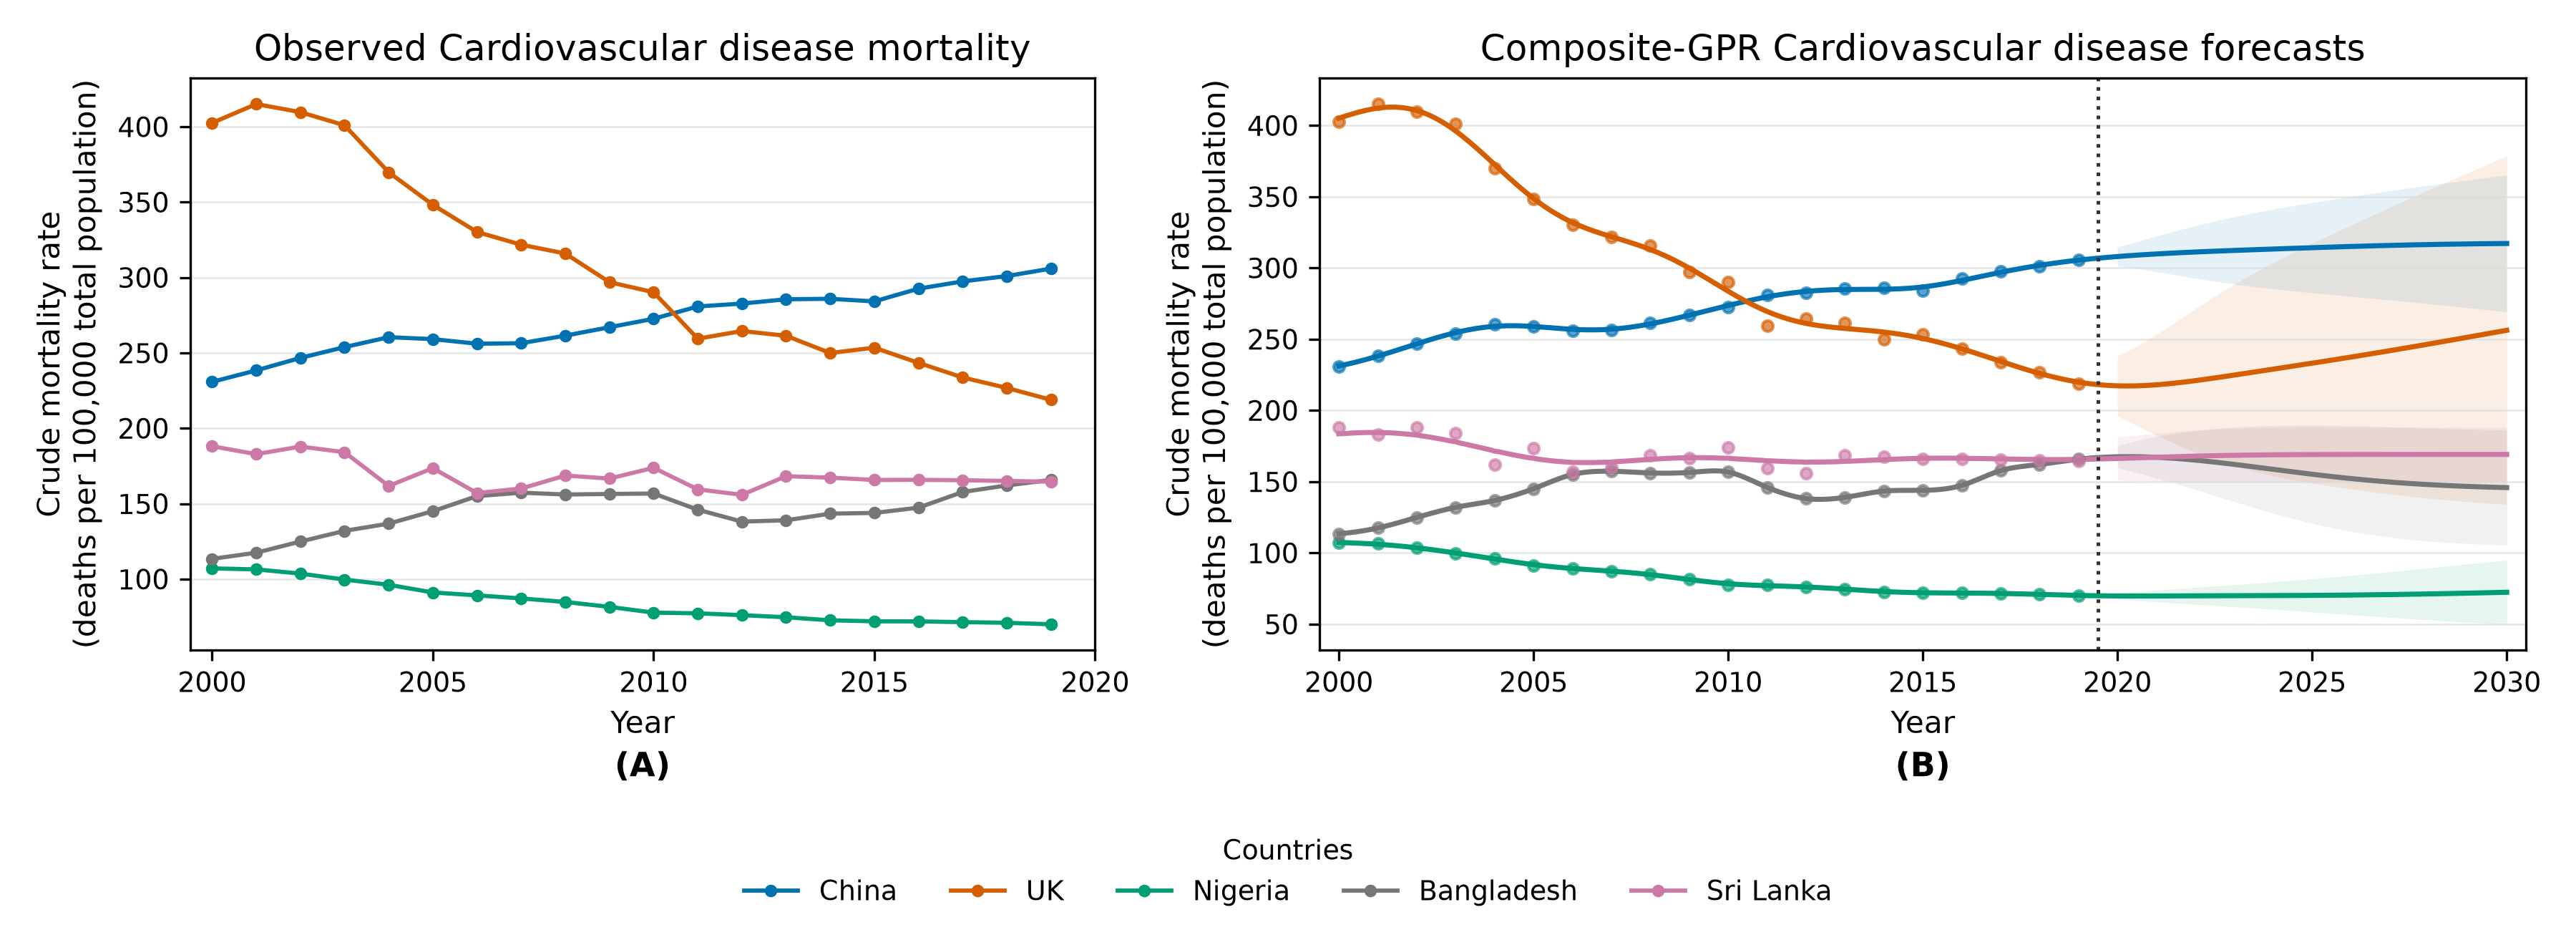

Displayed PNG: C:\Users\wathsala\Documents\NCD\GPR_Research_Results_Sex_Specific\Figure_Both_Sex_Cardiovascular_diseases.png


In [24]:
if DISPLAY_FIGURE_PREVIEWS and GENERATE_BOTH_SEX_FIGURES:
    display_saved_png(OUTPUT_DIR / "Figure_Both_Sex_Cardiovascular_diseases.png", width=1200)


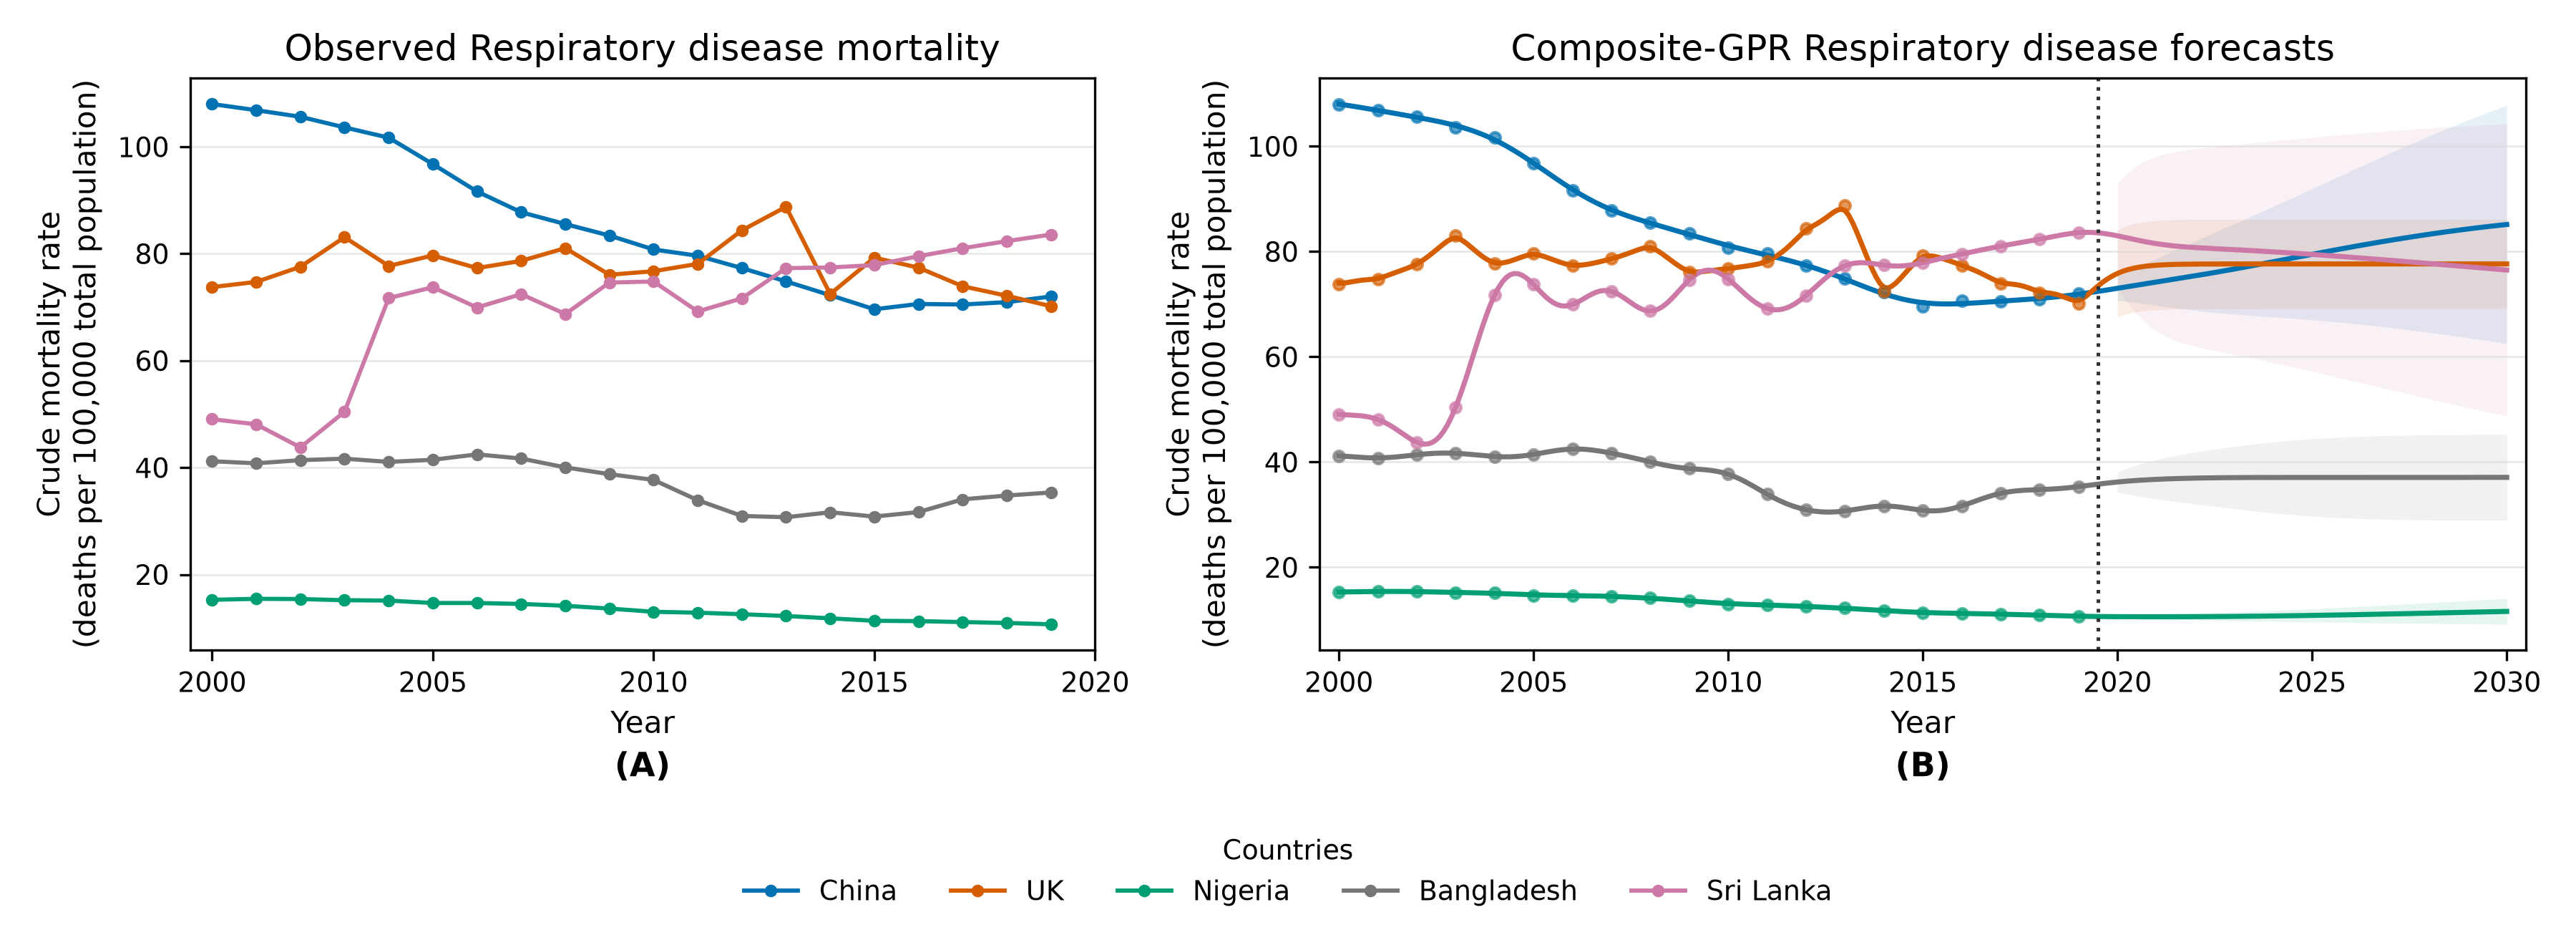

Displayed PNG: C:\Users\wathsala\Documents\NCD\GPR_Research_Results_Sex_Specific\Figure_Both_Sex_Respiratory_diseases.png


In [25]:
if DISPLAY_FIGURE_PREVIEWS and GENERATE_BOTH_SEX_FIGURES:
    display_saved_png(OUTPUT_DIR / "Figure_Both_Sex_Respiratory_diseases.png", width=1200)


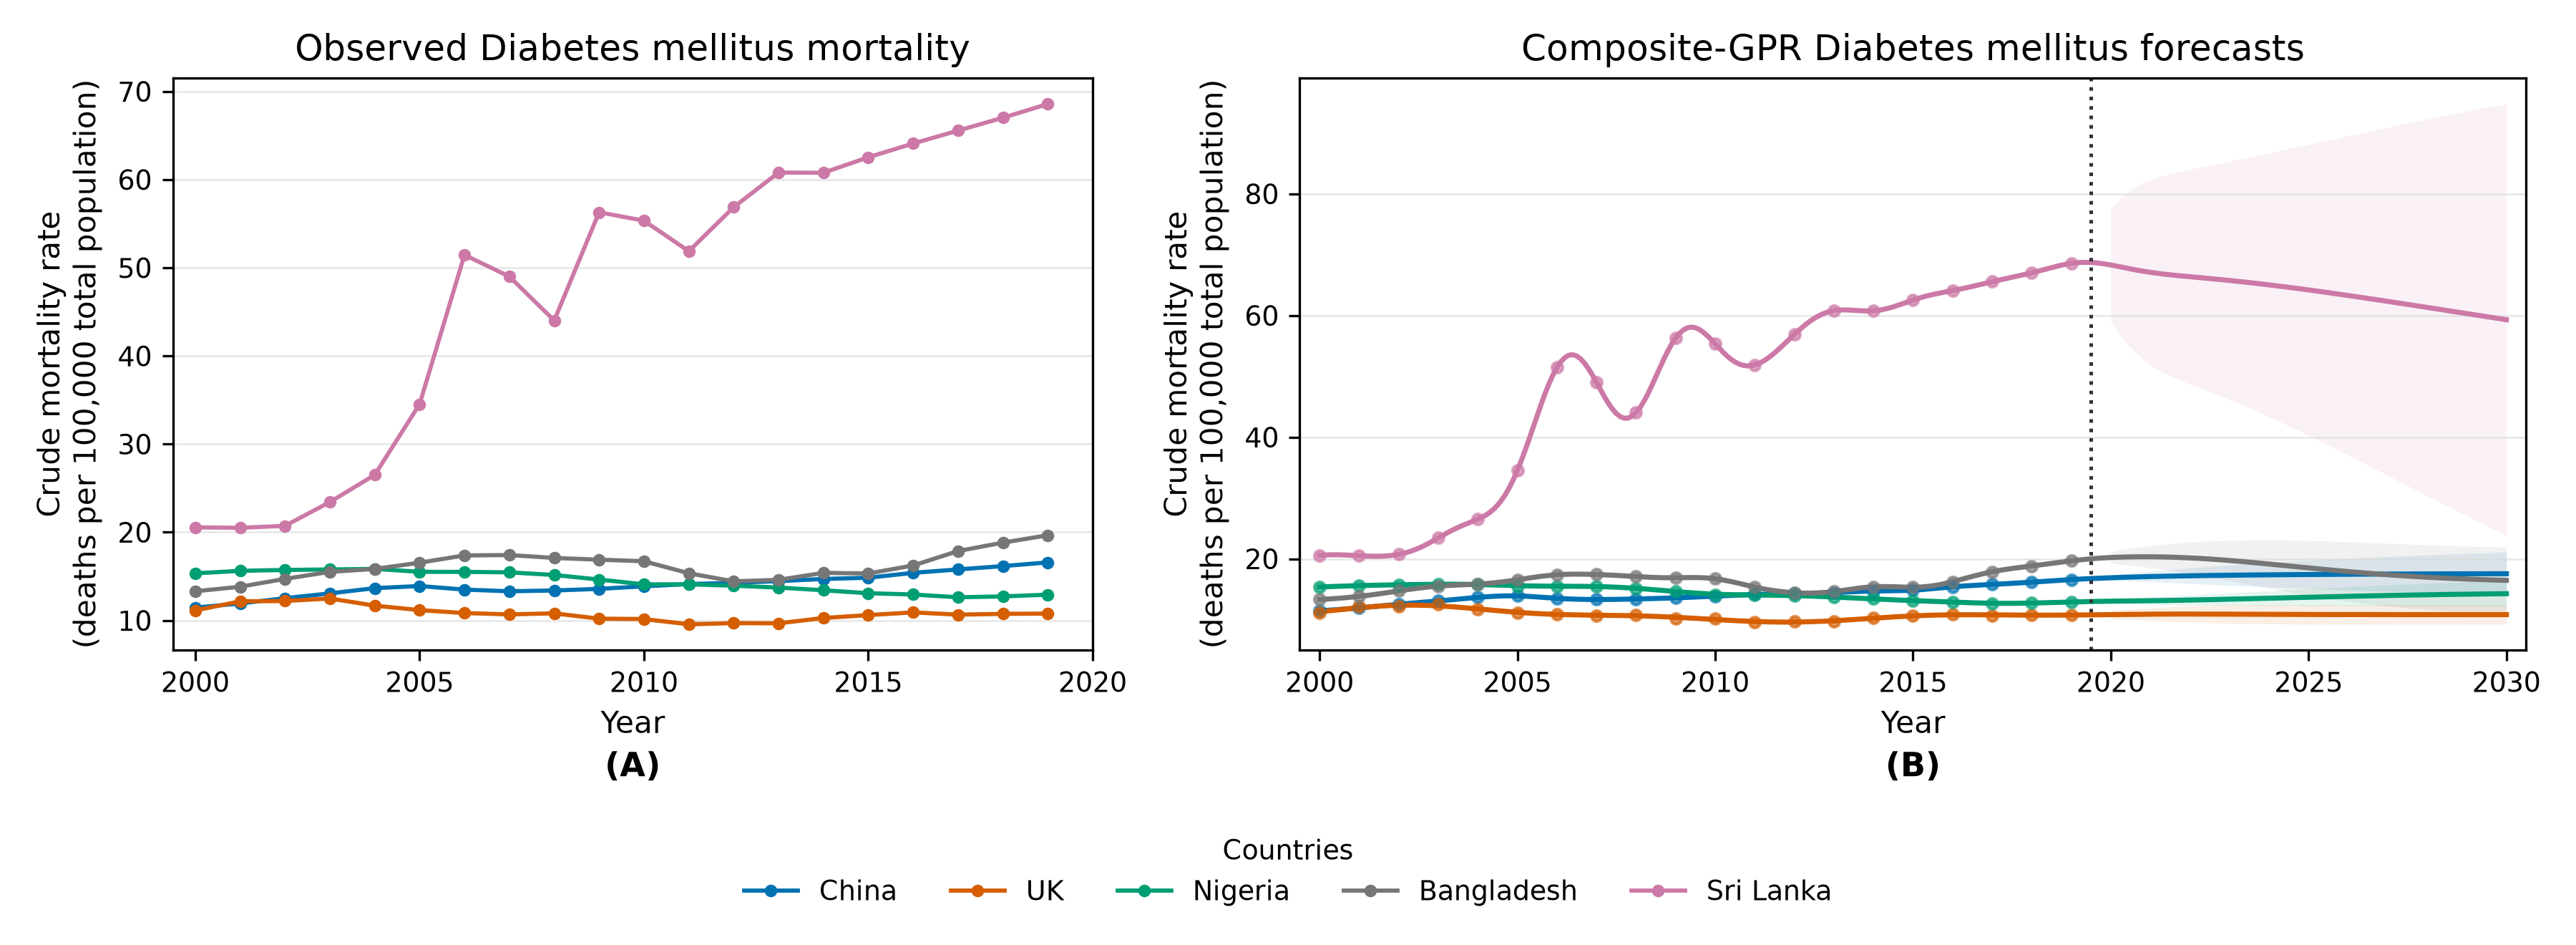

Displayed PNG: C:\Users\wathsala\Documents\NCD\GPR_Research_Results_Sex_Specific\Figure_Both_Sex_Diabetes_mellitus.png


In [26]:
if DISPLAY_FIGURE_PREVIEWS and GENERATE_BOTH_SEX_FIGURES:
    display_saved_png(OUTPUT_DIR / "Figure_Both_Sex_Diabetes_mellitus.png", width=1200)


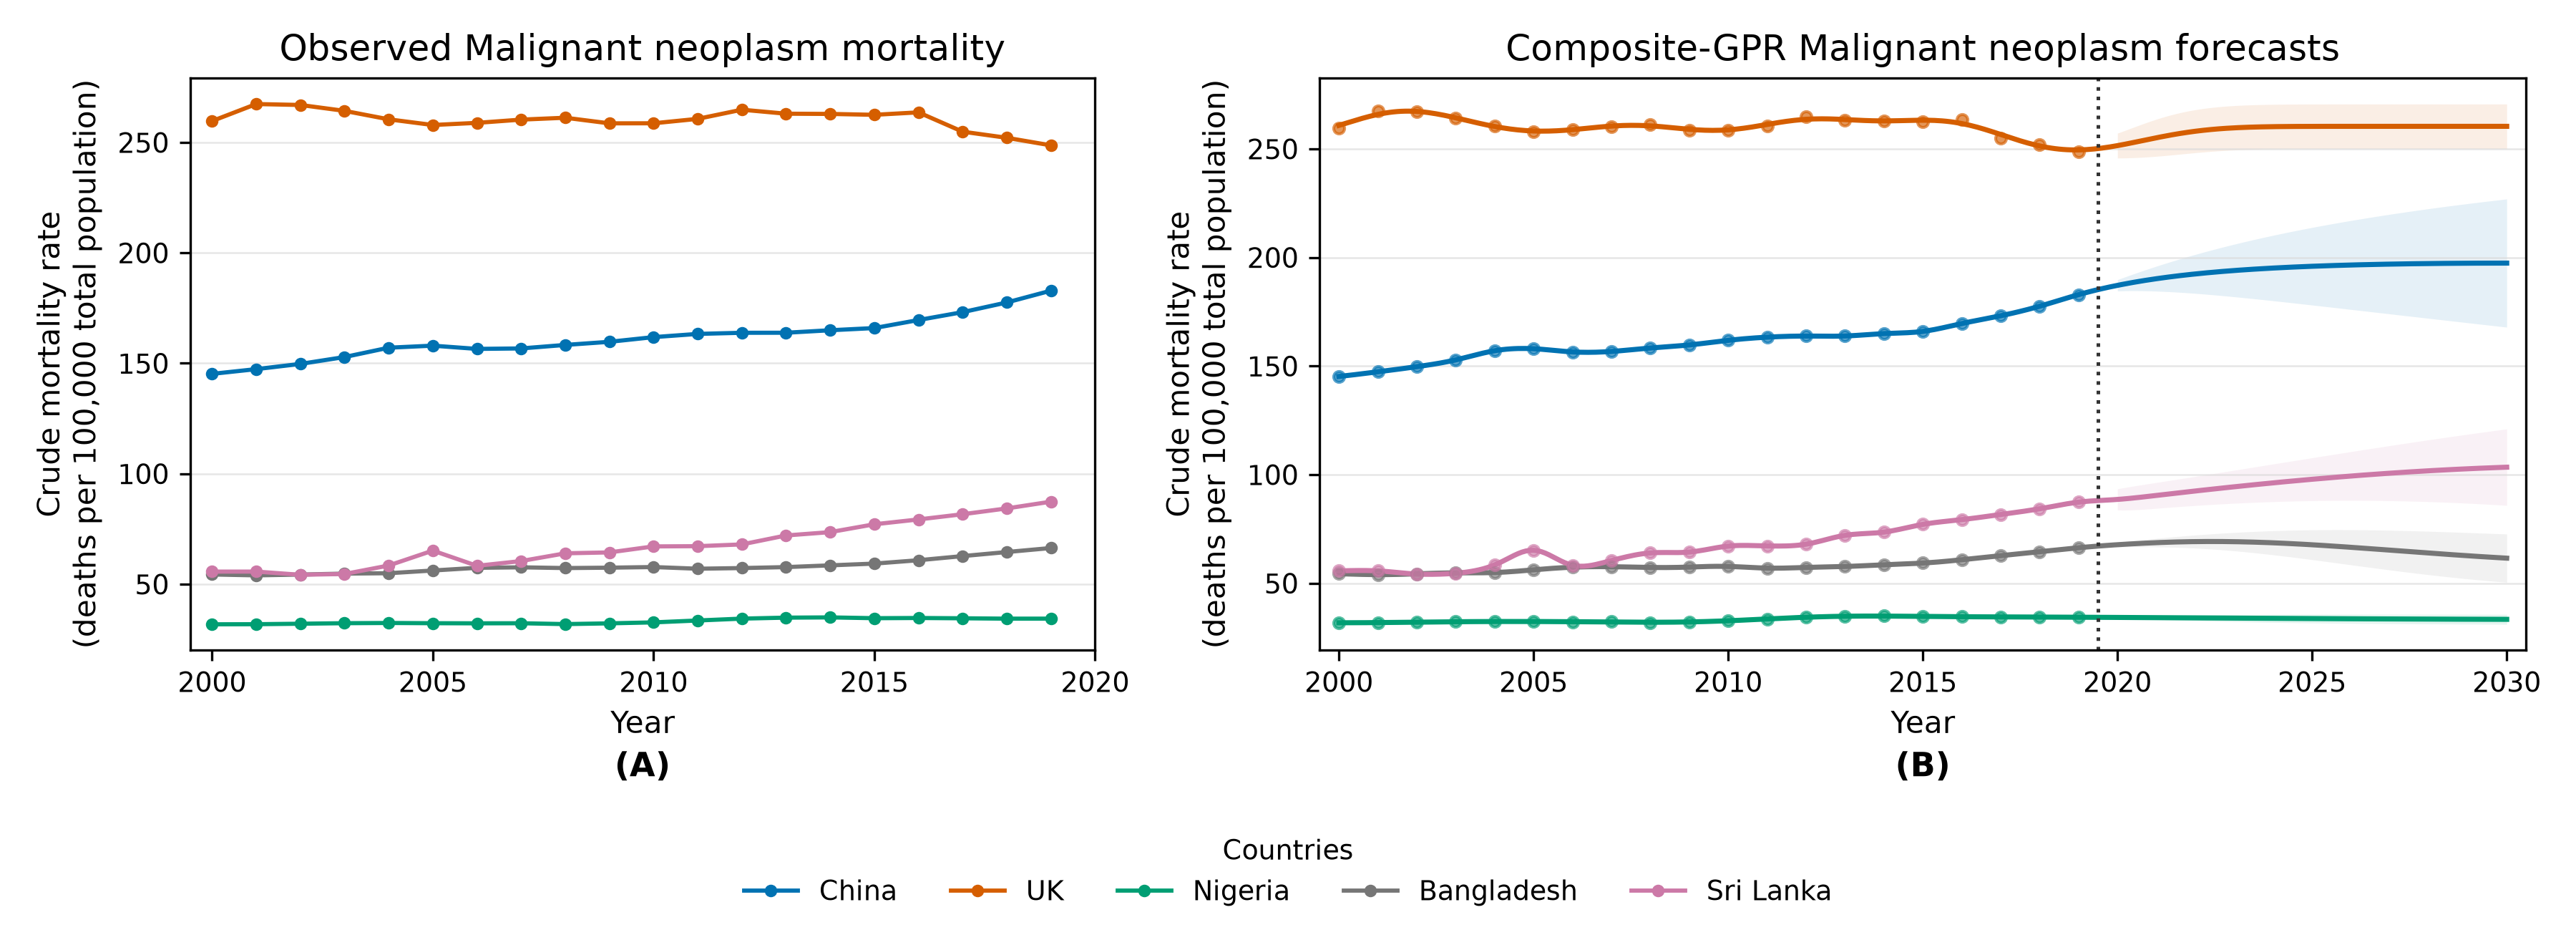

Displayed PNG: C:\Users\wathsala\Documents\NCD\GPR_Research_Results_Sex_Specific\Figure_Both_Sex_Malignant_neoplasms.png


In [27]:
if DISPLAY_FIGURE_PREVIEWS and GENERATE_BOTH_SEX_FIGURES:
    display_saved_png(OUTPUT_DIR / "Figure_Both_Sex_Malignant_neoplasms.png", width=1200)


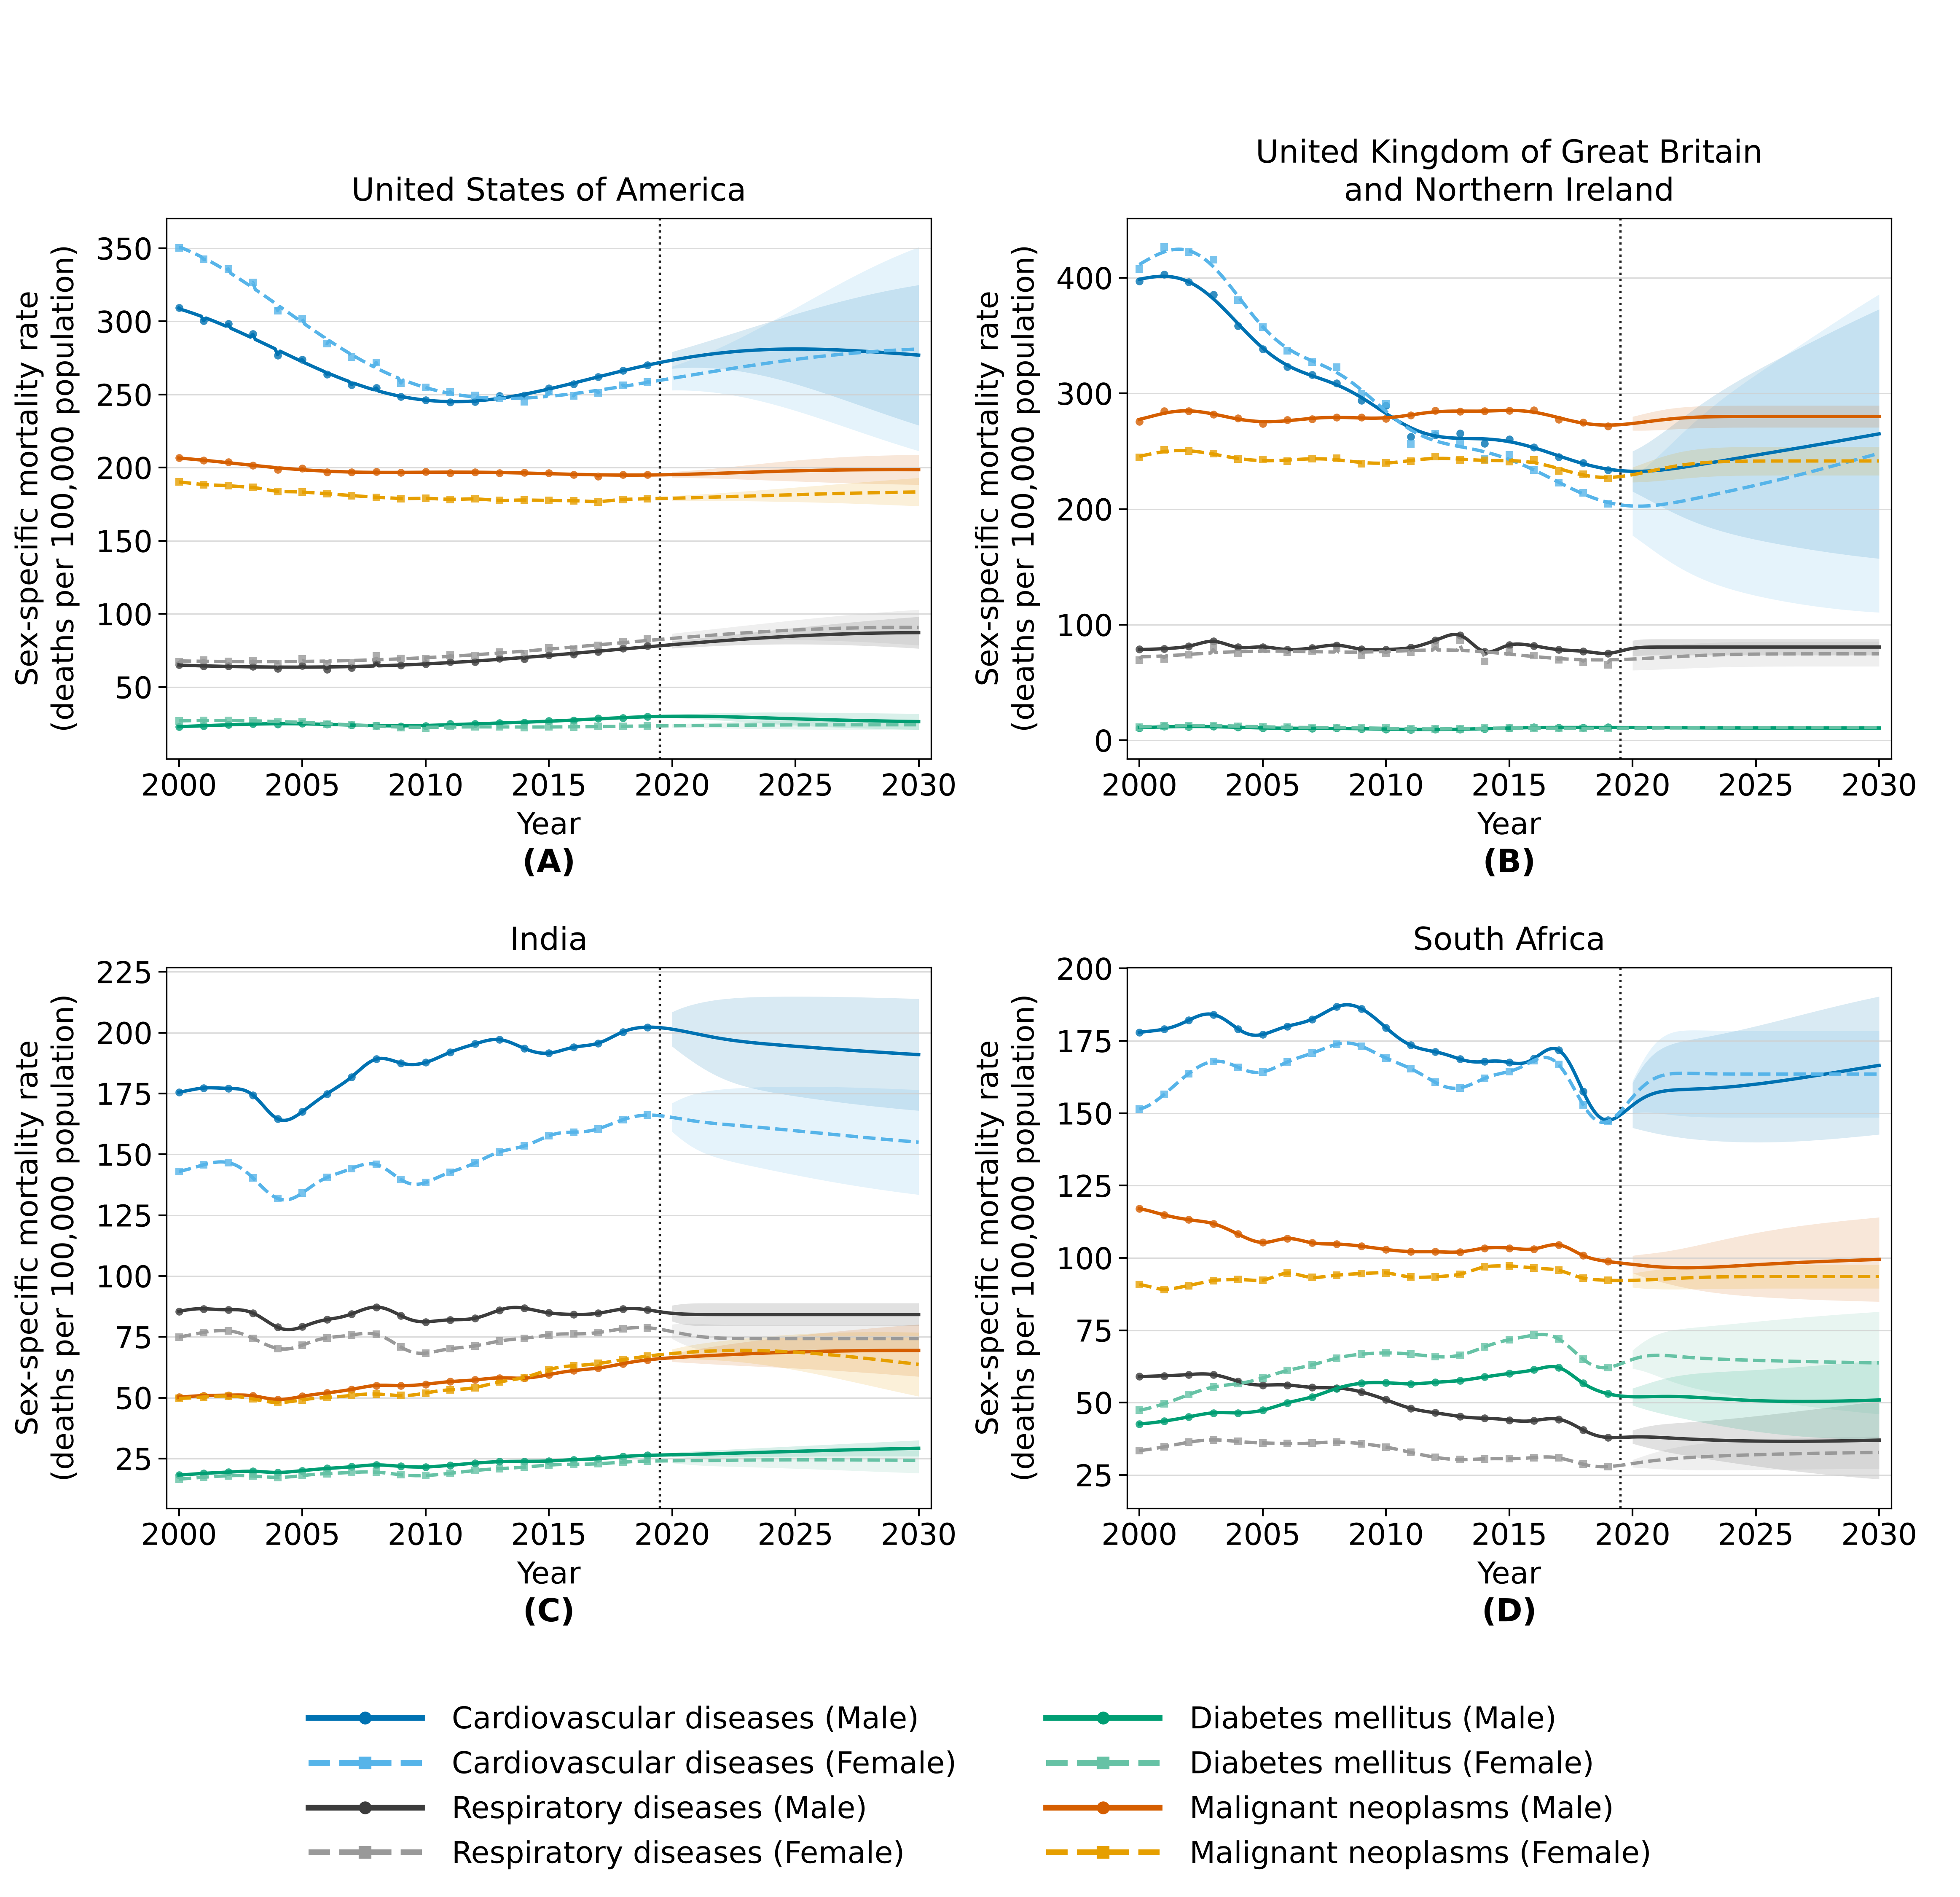

Displayed PNG: C:\Users\wathsala\Documents\NCD\GPR_Research_Results_Sex_Specific\Figure_Sex_Specific_NCD_Forecasts_Corrected.png


In [28]:
if DISPLAY_FIGURE_PREVIEWS:
    display_saved_png(sex_specific_figure_files["PNG"], width=1100)


In [29]:
# Optional TIFF export; enable EXPORT_OPTIONAL_TIFF in the settings cell.
if EXPORT_OPTIONAL_TIFF:
    from pathlib import Path
    from PIL import Image
    import gc
    
    # Folder containing the correctly generated PNG
    OUTPUT_DIR = Path("GPR_Research_Results_Sex_Specific")
    
    png_path = (
        OUTPUT_DIR
        / "Figure_Sex_Specific_NCD_Forecasts_Corrected.png"
    )
    
    tiff_path = (
        OUTPUT_DIR
        / "Figure_Sex_Specific_NCD_Forecasts_Corrected_300dpi.tiff"
    )
    
    if not png_path.exists():
        raise FileNotFoundError(
            f"PNG file not found:\n{png_path.resolve()}"
        )
    
    gc.collect()
    
    with Image.open(png_path) as source_image:
        source_image.load()
        original_size = source_image.size
    
        # Flatten onto white and remove the alpha channel for maximum
        # compatibility with journals and TIFF viewers.
        if "A" in source_image.getbands():
            rgba_image = source_image.convert("RGBA")
            rgb_image = Image.new(
                "RGB",
                rgba_image.size,
                color="white",
            )
            rgb_image.paste(
                rgba_image,
                mask=rgba_image.getchannel("A"),
            )
            rgba_image.close()
        else:
            rgb_image = source_image.convert("RGB")
    
        # This converts the existing pixels without resizing or redrawing.
        rgb_image.save(
            tiff_path,
            format="TIFF",
            compression="tiff_lzw",
            dpi=(300, 300),
        )
    
        rgb_image.close()
    
    gc.collect()
    
    # Validate the output without loading the entire TIFF again.
    with Image.open(tiff_path) as saved_tiff:
        if saved_tiff.size != original_size:
            raise RuntimeError(
                f"Image dimensions changed: "
                f"PNG={original_size}, TIFF={saved_tiff.size}"
            )
    
        print("TIFF saved successfully")
        print(f"File: {tiff_path.resolve()}")
        print(f"Dimensions: {saved_tiff.width} × {saved_tiff.height} pixels")
        print(f"Resolution: {saved_tiff.info.get('dpi')}")
        print(f"Colour mode: {saved_tiff.mode}")
        print(
            f"File size: "
            f"{tiff_path.stat().st_size / (1024 ** 2):.2f} MB"
        )


## Manuscript table comparison and fit diagnostics

The constants below are transcribed from Manuscript V23 Tables 3–5. They are
reference targets only. Differences are exported and warned about, never corrected
by replacing calculated results. A rounding tolerance of 0.000501 is used for the
three-decimal manuscript values.The recorded original run reported Python 3.14.6, NumPy 2.4.6, pandas 3.0.3 and
scikit-learn 1.9.0; those are supplied-output provenance, not versions independently
verified here. Exact optimisation results may vary with the numerical environment.

In [30]:
metric_columns = ["MAE", "RMSE", "MAPE (%)", "95% PI Coverage (%)"]
reference_primary = {
    "Proposed composite GPR": [5.321, 6.282, 5.870, 79.762],
    "Linear Trend Regression": [5.932, 6.558, 6.954, np.nan],
    "Standard GPR-RBF": [7.551, 8.584, 8.413, 70.714],
}
reference_rolling = {
    "Proposed composite GPR": [5.904, 6.716, 6.743, 75.190],
    "Linear Trend Regression": [6.136, 6.589, 7.267, np.nan],
    "Standard GPR-RBF": [7.613, 8.450, 9.030, 64.381],
}
reference_folds = {
    "Linear Trend Regression": [[6.528,6.986,8.304],[6.457,6.844,7.650],[5.980,6.305,6.761],[5.780,6.252,6.668],[5.932,6.558,6.954]],
    "Proposed composite GPR": [[6.256,6.894,7.460],[5.230,5.856,7.138],[6.585,7.458,7.157],[6.129,7.090,6.089],[5.321,6.282,5.870]],
    "Standard GPR-RBF": [[7.737,8.414,9.518],[6.633,7.317,9.184],[8.403,9.334,9.859],[7.742,8.600,8.177],[7.551,8.584,8.413]],
}
comparison_rows = []
def compare_reference(label, computed, reference, columns):
    indexed = computed.set_index("Model")
    for model, values in reference.items():
        for metric, target in zip(columns, values):
            actual = float(indexed.loc[model, metric])
            matches = bool(np.isnan(actual)) if np.isnan(target) else bool(np.isfinite(actual) and abs(actual-target) <= 0.000501)
            comparison_rows.append({"Table": label, "Model": model, "Metric": metric,
                                    "Computed": actual, "Manuscript": target, "Matches": matches})
compare_reference("Primary", holdout_macro, reference_primary, metric_columns)
compare_reference("Rolling mean", rolling_macro, reference_rolling, metric_columns)
for fold in range(1,6):
    compare_reference(f"Rolling fold {fold}", rolling_by_fold[rolling_by_fold["Fold"] == fold],
                      {model: rows[fold-1] for model,rows in reference_folds.items()}, metric_columns[:3])
comparison = pd.DataFrame(comparison_rows)
comparison.to_csv(OUTPUT_DIR / "Manuscript_Table_Check.csv", index=False)
display(comparison)
if not comparison["Matches"].all():
    warnings.warn("Computed results differ from manuscript rounding; inspect Manuscript_Table_Check.csv.")
fold5 = rolling_by_fold[rolling_by_fold["Fold"] == 5].set_index("Model").sort_index()
primary = holdout_macro.set_index("Model").sort_index()
if not np.allclose(fold5[metric_columns], primary[metric_columns], rtol=1e-7, atol=1e-7, equal_nan=True):
    raise AssertionError("Rolling fold 5 does not reproduce the primary split.")
for name, table in [("Holdout", holdout_metrics_df), ("Rolling", rolling_metrics_df), ("Final", final_model_fit_df)]:
    flagged = table[table["Convergence warning count"] > 0]
    flagged.to_csv(OUTPUT_DIR / f"{name}_Convergence_Warnings.csv", index=False)
    print(f"{name}: {len(flagged)} model fits with convergence warnings; inspect exported diagnostics.")


,Table,Model,Metric,Computed,Manuscript,Matches
0,Primary,Proposed composite GPR,MAE,5.320877,5.321,True
1,Primary,Proposed composite GPR,RMSE,6.281969,6.282,True
2,Primary,Proposed composite GPR,MAPE (%),5.870061,5.870,True
3,Primary,Proposed composite GPR,95% PI Coverage (%),79.761905,79.762,True
4,Primary,Linear Trend Regression,MAE,5.931902,5.932,True
...,...,...,...,...,...,...
64,Rolling fold 5,Proposed composite GPR,RMSE,6.281969,6.282,True
65,Rolling fold 5,Proposed composite GPR,MAPE (%),5.870061,5.870,True
66,Rolling fold 5,Standard GPR-RBF,MAE,7.550984,7.551,True
67,Rolling fold 5,Standard GPR-RBF,RMSE,8.584124,8.584,True


Holdout: 87 model fits with convergence warnings; inspect exported diagnostics.
Rolling: 435 model fits with convergence warnings; inspect exported diagnostics.
Final: 94 model fits with convergence warnings; inspect exported diagnostics.
